# Member 3 — ResNet50 Transfer Learning

## Comparative Analysis of Deep Learning Architectures for Multi-Class Brain Tumour MRI Classification

**SE4050 – Deep Learning 2026**

This notebook implements a ResNet50 transfer-learning model for classifying brain tumour MRI images into four classes: **glioma**, **meningioma**, **notumor**, and **pituitary**.

### Architectural Context & Scientific Comparison
ResNet50 introduces **deep residual learning** via residual connections (identity shortcut mappings), addressing the vanishing gradient problem in very deep networks (He et al., 2016). Unlike VGG16 (a purely sequential deep network with standard feed-forward convolutional stacks), ResNet50 utilizes bottleneck residual blocks (`1x1` projection -> `3x3` conv -> `1x1` expansion) with skip connections and Batch Normalization.

---

### Important Scientific Limitations
1. **Transfer Learning Limitation:** ResNet50 starts from ImageNet pretrained weights, whereas Member 1's Custom CNN was trained from scratch. The comparison evaluates practical transfer-learning paradigms against custom from-scratch training, not an isolated architecture-only benchmark.
2. **Patient-Level Independence Limitation:** Patient-level independence could not be independently verified from the available dataset structure and identifiers. All analyses report image-level generalization.

---
## Phase 1 — Environment Verification and ResNet50 Preprocessing Pipeline

**Goal:** Verify environment reproducibility, validate Member 1's frozen split manifests via SHA-256 checksums, and construct the ResNet50-specific `tf.data` input pipeline.

### Phase 1 Tasks
1. Record complete runtime environment (Python, TensorFlow, Keras, NumPy, Pandas, scikit-learn, GPU, determinism).
2. Verify SHA-256 checksums for all three frozen split CSV files (`train.csv`, `val.csv`, `test.csv`).
3. Download exact Kaggle dataset version 1 (`masoudnickparvar/brain-tumor-mri-dataset/versions/1`).
4. Verify frozen sample counts: Train = 4,353, Validation = 1,089, Test = 1,311.
5. Verify frozen class mapping: `glioma: 0`, `meningioma: 1`, `notumor: 2`, `pituitary: 3`.
6. Verify that every referenced image file exists on disk.
7. Build ResNet50-specific `tf.data` pipeline using `keras.applications.resnet50.preprocess_input` (NO `Rescaling(1./255)`).
8. Apply common mild augmentation to training data only (rotation $\approx 0.03$, zoom $\approx \pm 0.08$, translation $\approx 0.05$).
9. Verify batch shapes, label integrity, and unshuffled validation stream.
10. Verify held-out test manifest without creating an evaluation dataset.
11. Save Phase 1 configuration and environment manifest.

### 1.1 — Install Dependencies and Imports

In [1]:
# Install kagglehub if not already present in environment
!pip install -q kagglehub

import os
import sys
import json
import hashlib
import time
import random
import platform
import shutil
import subprocess
import gc

import numpy as np
import pandas as pd
import tensorflow as tf
import keras
import sklearn
import kagglehub
import matplotlib
import matplotlib.pyplot as plt

# Architecture-specific preprocessor for ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess_input

print("All imports completed successfully.")

All imports completed successfully.


### 1.2 — Set Random Seeds and Determinism

We fix the random seed to 42 across all libraries to ensure reproducible initialization, data shuffling, and pipeline execution. Deterministic op execution is requested where supported by hardware.

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
    determinism_status = "TensorFlow op determinism enabled"
except Exception as e:
    determinism_status = f"Could not enable op determinism: {e}"

print(f"Seed:        {SEED}")
print(f"Determinism: {determinism_status}")

Seed:        42
Determinism: TensorFlow op determinism enabled


### 1.3 — Record Full Environment Information

In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        gpu_name = subprocess.check_output(
            ['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'],
            text=True,
        ).strip().splitlines()[0]
        nvidia_smi = subprocess.check_output(
            ['nvidia-smi', '--query-gpu=name,driver_version,memory.total', '--format=csv,noheader'],
            text=True,
        ).strip().splitlines()[0]
    except Exception:
        gpu_name = tf.config.experimental.get_device_details(gpus[0]).get('device_name', 'Unknown GPU')
        nvidia_smi = 'Unavailable'
else:
    gpu_name = 'No GPU detected'
    nvidia_smi = 'N/A'

environment_info = {
    'member': 3,
    'model': 'ResNet50',
    'python_version': sys.version,
    'platform': platform.platform(),
    'tensorflow_version': tf.__version__,
    'keras_version': keras.__version__,
    'numpy_version': np.__version__,
    'pandas_version': pd.__version__,
    'scikit_learn_version': sklearn.__version__,
    'kagglehub_version': getattr(kagglehub, '__version__', 'unknown'),
    'matplotlib_version': matplotlib.__version__,
    'gpu_name': gpu_name,
    'nvidia_smi': nvidia_smi,
    'seed': SEED,
    'determinism_status': determinism_status,
}

print('Environment Recorded:')
for k, v in environment_info.items():
    print(f'  {k:<22}: {v}')

Environment Recorded:
  member                : 3
  model                 : ResNet50
  python_version        : 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
  platform              : Linux-6.6.122+-x86_64-with-glibc2.39
  tensorflow_version    : 2.20.0
  keras_version         : 3.13.2
  numpy_version         : 2.1.3
  pandas_version        : 2.2.3
  scikit_learn_version  : 1.6.1
  kagglehub_version     : 1.0.2
  matplotlib_version    : 3.10.0
  gpu_name              : Tesla T4
  nvidia_smi            : Tesla T4, 580.82.07, 15360 MiB
  seed                  : 42
  determinism_status    : TensorFlow op determinism enabled


### 1.4 — Download Pinned Kaggle Dataset (Version 1)

In strict compliance with the shared protocol, we download only the explicit pinned version 1 (`masoudnickparvar/brain-tumor-mri-dataset/versions/1`).

In [4]:
DATASET_HANDLE = "masoudnickparvar/brain-tumor-mri-dataset"
DATASET_VERSION = 1
PINNED_HANDLE = f"{DATASET_HANDLE}/versions/{DATASET_VERSION}"

dataset_path = kagglehub.dataset_download(PINNED_HANDLE)
print(f"Pinned Dataset Handle: {PINNED_HANDLE}")
print(f"Dataset downloaded to: {dataset_path}")
print(f"Dataset root contents: {os.listdir(dataset_path)}")

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Pinned Dataset Handle: masoudnickparvar/brain-tumor-mri-dataset/versions/1
Dataset downloaded to: /kaggle/input/brain-tumor-mri-dataset
Dataset root contents: ['Training', 'Testing']


### 1.5 — Define Project Paths

In [6]:
from pathlib import Path
import os
import shutil
import subprocess

# ============================================================
# FRESH-COLAB PROJECT BOOTSTRAP
# ============================================================

REPO_URL = (
    "https://github.com/ramzyhafeel/"
    "brain_tumour_model_comparison.git"
)

PROJECT_ROOT = Path(
    "/content/brain_tumour_model_comparison"
)


def ensure_project_available():
    """
    Ensure the complete GitHub project exists
    in the current fresh Colab runtime.
    """

    required_items = [
        PROJECT_ROOT / "splits" / "train.csv",
        PROJECT_ROOT / "splits" / "val.csv",
        PROJECT_ROOT / "splits" / "test.csv",
        PROJECT_ROOT / "config",
        PROJECT_ROOT / "notebooks",
    ]

    if (
        PROJECT_ROOT.exists()
        and all(item.exists() for item in required_items)
    ):
        print("✓ Project repository already available.")
        return PROJECT_ROOT

    print("Project repository not found in this runtime.")
    print("Cloning GitHub repository...")

    if PROJECT_ROOT.exists():
        shutil.rmtree(PROJECT_ROOT)

    subprocess.run(
        [
            "git",
            "clone",
            REPO_URL,
            str(PROJECT_ROOT),
        ],
        check=True,
    )

    missing = [
        str(item)
        for item in required_items
        if not item.exists()
    ]

    if missing:
        raise FileNotFoundError(
            "Repository cloned, but required project "
            f"files/folders are missing:\n{missing}"
        )

    print("✓ Repository cloned successfully.")
    return PROJECT_ROOT


# ============================================================
# INITIALIZE PROJECT PATHS
# ============================================================

PROJECT_ROOT = ensure_project_available()

# Alias in case later cells expect PROJECT_DIR
PROJECT_DIR = PROJECT_ROOT

SPLITS_DIR = PROJECT_ROOT / "splits"
CONFIG_DIR = PROJECT_ROOT / "config"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

RESULTS_DIR = PROJECT_ROOT / "results" / "resnet50"
MODELS_DIR = PROJECT_ROOT / "models" / "resnet50"

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Split file variables used by later cells
TRAIN_CSV = SPLITS_DIR / "train.csv"
VAL_CSV = SPLITS_DIR / "val.csv"
TEST_CSV = SPLITS_DIR / "test.csv"

os.chdir(PROJECT_ROOT)


# ============================================================
# VERIFY PROJECT
# ============================================================

print("\n" + "=" * 70)
print("PROJECT SETUP")
print("=" * 70)

print("Project root :", PROJECT_ROOT)
print("Splits       :", SPLITS_DIR)
print("Config       :", CONFIG_DIR)
print("Notebooks    :", NOTEBOOKS_DIR)
print("Results      :", RESULTS_DIR)
print("Models       :", MODELS_DIR)

print("\nSplit files:")
print("train.csv    :", TRAIN_CSV)
print("val.csv      :", VAL_CSV)
print("test.csv     :", TEST_CSV)

assert TRAIN_CSV.is_file(), (
    f"train.csv missing: {TRAIN_CSV}"
)

assert VAL_CSV.is_file(), (
    f"val.csv missing: {VAL_CSV}"
)

assert TEST_CSV.is_file(), (
    f"test.csv missing: {TEST_CSV}"
)

assert CONFIG_DIR.exists(), (
    f"Config directory missing: {CONFIG_DIR}"
)

print("\nWorking directory:", Path.cwd())

print("\n✓ train.csv found")
print("✓ val.csv found")
print("✓ test.csv found")
print("✓ PROJECT READY")

Project repository not found in this runtime.
Cloning GitHub repository...
✓ Repository cloned successfully.

PROJECT SETUP
Project root : /content/brain_tumour_model_comparison
Splits       : /content/brain_tumour_model_comparison/splits
Config       : /content/brain_tumour_model_comparison/config
Notebooks    : /content/brain_tumour_model_comparison/notebooks
Results      : /content/brain_tumour_model_comparison/results/resnet50
Models       : /content/brain_tumour_model_comparison/models/resnet50

Split files:
train.csv    : /content/brain_tumour_model_comparison/splits/train.csv
val.csv      : /content/brain_tumour_model_comparison/splits/val.csv
test.csv     : /content/brain_tumour_model_comparison/splits/test.csv

Working directory: /content/brain_tumour_model_comparison

✓ train.csv found
✓ val.csv found
✓ test.csv found
✓ PROJECT READY


### 1.6 — Verify Frozen Split Checksums (SHA-256)

Before any model development, we verify the SHA-256 hashes of all three split CSV files against the frozen manifests created by Member 1. If any hash differs, execution is terminated immediately.

In [7]:
EXPECTED_CHECKSUMS = {
    "train.csv": "7273ef5fc2cb605c5b03b22a23cda0cb383ac0d9ce5949ac3c95649b5a4270cb",
    "val.csv":   "37b24456cfcd1b69df939e36603958eae6a9124b794c32c83a532b9018c6c88f",
    "test.csv":  "9afc40a38949eb4f46f8c9591d3b1f51cdd11aa991bfe2cf1d15c386c5537d39"
}

def compute_sha256(filepath):
    """Compute SHA-256 hash of a file."""
    hasher = hashlib.sha256()
    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(65536), b""):
            hasher.update(chunk)
    return hasher.hexdigest()

checksums_verified = True
computed_checksums = {}

for filename, expected_hash in EXPECTED_CHECKSUMS.items():
    filepath = os.path.join(SPLITS_DIR, filename)
    if not os.path.exists(filepath):
        print(f"ERROR: {filepath} missing!")
        checksums_verified = False
        continue

    actual_hash = compute_sha256(filepath)
    computed_checksums[filename] = actual_hash
    matches = (actual_hash == expected_hash)
    if not matches:
        checksums_verified = False

    status = "MATCH" if matches else "MISMATCH"
    print(f"{filename:<10}: {status}")
    print(f"  Expected: {expected_hash}")
    print(f"  Computed: {actual_hash}")

if not checksums_verified:
    raise RuntimeError("STOP: Split manifest checksum mismatch! Do not proceed.")
else:
    print("\nAll three split checksums verified successfully.")

train.csv : MATCH
  Expected: 7273ef5fc2cb605c5b03b22a23cda0cb383ac0d9ce5949ac3c95649b5a4270cb
  Computed: 7273ef5fc2cb605c5b03b22a23cda0cb383ac0d9ce5949ac3c95649b5a4270cb
val.csv   : MATCH
  Expected: 37b24456cfcd1b69df939e36603958eae6a9124b794c32c83a532b9018c6c88f
  Computed: 37b24456cfcd1b69df939e36603958eae6a9124b794c32c83a532b9018c6c88f
test.csv  : MATCH
  Expected: 9afc40a38949eb4f46f8c9591d3b1f51cdd11aa991bfe2cf1d15c386c5537d39
  Computed: 9afc40a38949eb4f46f8c9591d3b1f51cdd11aa991bfe2cf1d15c386c5537d39

All three split checksums verified successfully.


### 1.7 — Load Split CSVs and Verify Sample Counts

In [8]:
train_df = pd.read_csv(os.path.join(SPLITS_DIR, "train.csv"))
val_df   = pd.read_csv(os.path.join(SPLITS_DIR, "val.csv"))
test_df  = pd.read_csv(os.path.join(SPLITS_DIR, "test.csv"))

EXPECTED_TRAIN = 4353
EXPECTED_VAL   = 1089
EXPECTED_TEST  = 1311

print(f"Train samples: {len(train_df):<5} (expected {EXPECTED_TRAIN})")
print(f"Val samples:   {len(val_df):<5} (expected {EXPECTED_VAL})")
print(f"Test samples:  {len(test_df):<5} (expected {EXPECTED_TEST})")

assert len(train_df) == EXPECTED_TRAIN, f"Train count mismatch: {len(train_df)}"
assert len(val_df)   == EXPECTED_VAL,   f"Val count mismatch: {len(val_df)}"
assert len(test_df)  == EXPECTED_TEST,  f"Test count mismatch: {len(test_df)}"
print("\nAll sample counts match expected frozen split sizes.")

Train samples: 4353  (expected 4353)
Val samples:   1089  (expected 1089)
Test samples:  1311  (expected 1311)

All sample counts match expected frozen split sizes.


### 1.8 — Verify Class Names and Index Mapping

The class mapping must remain strictly identical across all models:
`glioma: 0`, `meningioma: 1`, `notumor: 2`, `pituitary: 3`.

In [9]:
CLASS_NAMES = ["glioma", "meningioma", "notumor", "pituitary"]
CLASS_TO_INDEX = {name: idx for idx, name in enumerate(CLASS_NAMES)}

with open(os.path.join(CONFIG_DIR, "class_to_index.json"), "r") as f:
    frozen_class_mapping = json.load(f)

print("Class Mapping Verification:")
for name, idx in frozen_class_mapping.items():
    print(f"  {name:<12} -> {idx}")

assert CLASS_TO_INDEX == frozen_class_mapping, "Class mapping mismatch!"

# Verify class distributions in splits
for split_name, df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"\n{split_name} Distribution:")
    dist = df["label"].value_counts().sort_index()
    for cls_name in CLASS_NAMES:
        print(f"  {cls_name:<12}: {dist.get(cls_name, 0)}")

Class Mapping Verification:
  glioma       -> 0
  meningioma   -> 1
  notumor      -> 2
  pituitary    -> 3

Train Distribution:
  glioma      : 1057
  meningioma  : 1064
  notumor     : 1080
  pituitary   : 1152

Validation Distribution:
  glioma      : 264
  meningioma  : 267
  notumor     : 270
  pituitary   : 288

Test Distribution:
  glioma      : 300
  meningioma  : 306
  notumor     : 405
  pituitary   : 300


### 1.9 — Verify That Every Referenced Image Exists on Disk

In [10]:
missing_images = []
for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    for _, row in df.iterrows():
        full_path = os.path.join(dataset_path, row["filepath"])
        if not os.path.isfile(full_path):
            missing_images.append((split_name, row["filepath"]))

if missing_images:
    print(f"ERROR: {len(missing_images)} images missing!")
    raise RuntimeError("Missing image files detected.")
else:
    total_images = len(train_df) + len(val_df) + len(test_df)
    print(f"All {total_images} referenced images verified on disk.")

All 6753 referenced images verified on disk.


---
## ResNet50-Specific Preprocessing Pipeline

### Why `keras.applications.resnet50.preprocess_input` instead of `Rescaling(1./255)`?

Pretrained ResNet50 in Keras was trained with the standard Caffe-style preprocessing pipeline:
1. Converts RGB to BGR.
2. Zero-centers each color channel with respect to ImageNet channel means: $[103.939, 116.779, 123.68]$.
3. Operates on raw float pixel values in $[0, 255]$.

**Critical Rule:** Applying `Rescaling(1./255)` before `resnet50.preprocess_input` would result in **inappropriate double normalization**, scaling images to $[0, 1]$ and then subtracting $\approx 100$, producing severely corrupted activations. The image decoder therefore outputs float32 values in $[0, 255]$, and `resnet50.preprocess_input` handles the transformation.

### 1.10 — Define Pipeline Constants

In [11]:
IMAGE_HEIGHT = 224
IMAGE_WIDTH  = 224
CHANNELS     = 3
IMAGE_SIZE   = (IMAGE_HEIGHT, IMAGE_WIDTH)
INPUT_SHAPE  = (IMAGE_HEIGHT, IMAGE_WIDTH, CHANNELS)
BATCH_SIZE   = 16
NUM_CLASSES  = 4
MAX_EPOCHS   = 20

print(f"Image Shape:  {INPUT_SHAPE}")
print(f"Batch Size:   {BATCH_SIZE}")
print(f"Num Classes:  {NUM_CLASSES}")
print(f"Max Epochs:   {MAX_EPOCHS}")

Image Shape:  (224, 224, 3)
Batch Size:   16
Num Classes:  4
Max Epochs:   20


### 1.11 — Define Training-Only Augmentation Layer

We apply the exact same mild, conservative augmentation policy used by Custom CNN and VGG16:
- Random Rotation: factor = 0.03 ($\approx \pm 10.8^\circ$)
- Random Zoom: $\pm 8\%$
- Random Translation: $5\%$
Applied **strictly to training data**.

In [12]:
def make_augmentation(seed=SEED):
    return tf.keras.Sequential([
        tf.keras.layers.RandomRotation(factor=0.03, seed=seed),
        tf.keras.layers.RandomZoom(
            height_factor=(-0.08, 0.08),
            width_factor=(-0.08, 0.08),
            seed=seed,
        ),
        tf.keras.layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05,
            seed=seed,
        ),
    ], name='augmentation')

# Preview/smoke instance. Each controlled experiment gets a fresh instance.
augmentation_layer = make_augmentation(SEED)
print('Training-only augmentation factory defined.')

Training-only augmentation factory defined.


### 1.12 — Build `tf.data` Pipeline with ResNet50 Preprocessing

In [13]:
def decode_and_resize(filepath, label):
    """Decode JPEG, resize to 224x224 and keep float32 values in [0,255]."""
    raw = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(raw, channels=CHANNELS)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

def build_dataset(df, is_training=False):
    """Build raw-image tf.data pipeline. Model owns augmentation + preprocessing."""
    filepaths = [os.path.join(str(dataset_path), fp) for fp in df['filepath'].values]
    labels = [CLASS_TO_INDEX[lbl] for lbl in df['label'].values]
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if is_training:
        ds = ds.shuffle(
            buffer_size=len(filepaths),
            seed=SEED,
            reshuffle_each_iteration=True,
        )
    ds = ds.map(decode_and_resize, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE, drop_remainder=False)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

print('ResNet50 dataset builder defined.')
print('tf.data keeps pixels in raw [0,255] range; augmentation and ResNet50 preprocess_input run exactly once inside the model.')

ResNet50 dataset builder defined.
tf.data keeps pixels in raw [0,255] range; augmentation and ResNet50 preprocess_input run exactly once inside the model.


### 1.13 — Instantiate Training and Validation Datasets

In [14]:
train_ds = build_dataset(train_df, is_training=True)
val_ds   = build_dataset(val_df,   is_training=False)

train_batches = tf.data.experimental.cardinality(train_ds).numpy()
val_batches   = tf.data.experimental.cardinality(val_ds).numpy()

print(f"Training Batches:   {train_batches} ({len(train_df)} images)")
print(f"Validation Batches: {val_batches} ({len(val_df)} images)")

Training Batches:   273 (4353 images)
Validation Batches: 69 (1089 images)


### 1.14 — Verify Pipeline Output Properties

We verify that:
1. Output tensor shape is `(16, 224, 224, 3)`.
2. Mean subtraction produces negative pixel values (confirming `preprocess_input` executed).
3. All 4 class labels are present in the training stream.
4. Validation dataset is strictly unshuffled.

In [15]:
sample_images, sample_labels = next(iter(train_ds))
print('Batch Image Shape:', sample_images.shape)
print('Batch Label Shape:', sample_labels.shape)
print('Image Dtype:', sample_images.dtype)
print('Raw Pixel Min:', float(tf.reduce_min(sample_images)))
print('Raw Pixel Max:', float(tf.reduce_max(sample_images)))
print('Sample Labels:', sample_labels.numpy())

assert tuple(sample_images.shape[1:]) == (224, 224, 3)
assert float(tf.reduce_min(sample_images)) >= 0.0
assert float(tf.reduce_max(sample_images)) <= 255.0 + 1e-3

processed_probe = resnet50_preprocess_input(sample_images)
print('Preprocessed probe min:', float(tf.reduce_min(processed_probe)))
print('Preprocessed probe max:', float(tf.reduce_max(processed_probe)))
assert not np.allclose(processed_probe.numpy(), sample_images.numpy())
print('✓ Raw tf.data pipeline verified.')
print('✓ ResNet50 preprocess_input transforms raw images and will be applied inside the model exactly once.')

expected_first_val_labels = [CLASS_TO_INDEX[l] for l in val_df['label'].values[:BATCH_SIZE]]
_, val_labels_batch = next(iter(val_ds))
actual_first_val_labels = val_labels_batch.numpy().tolist()
assert expected_first_val_labels == actual_first_val_labels, 'Validation dataset is shuffled!'
print('✓ Validation stream verified: unshuffled.')

Batch Image Shape: (16, 224, 224, 3)
Batch Label Shape: (16,)
Image Dtype: <dtype: 'float32'>
Raw Pixel Min: 0.0
Raw Pixel Max: 255.0
Sample Labels: [0 3 2 3 1 1 2 1 0 1 1 0 1 2 0 1]
Preprocessed probe min: -123.68000030517578
Preprocessed probe max: 151.06100463867188
✓ Raw tf.data pipeline verified.
✓ ResNet50 preprocess_input transforms raw images and will be applied inside the model exactly once.
✓ Validation stream verified: unshuffled.


### 1.15 — Verify Held-Out Test Manifest (No Evaluation Dataset Created)

In strict accordance with the held-out test set rule, we verify the test manifest rows and image paths on disk, but do **NOT** instantiate a test `tf.data.Dataset` for evaluation.

In [16]:
print("Held-Out Test Manifest Verification:")
print(f"  Total Test Images: {len(test_df)}")
for cls_name in CLASS_NAMES:
    count = int(np.sum(test_df["label"] == cls_name))
    print(f"    {cls_name:<12}: {count}")

print("\nTest manifest verified. No test evaluation dataset created.")

Held-Out Test Manifest Verification:
  Total Test Images: 1311
    glioma      : 300
    meningioma  : 306
    notumor     : 405
    pituitary   : 300

Test manifest verified. No test evaluation dataset created.


### 1.16 — Pipeline Visual Demonstration

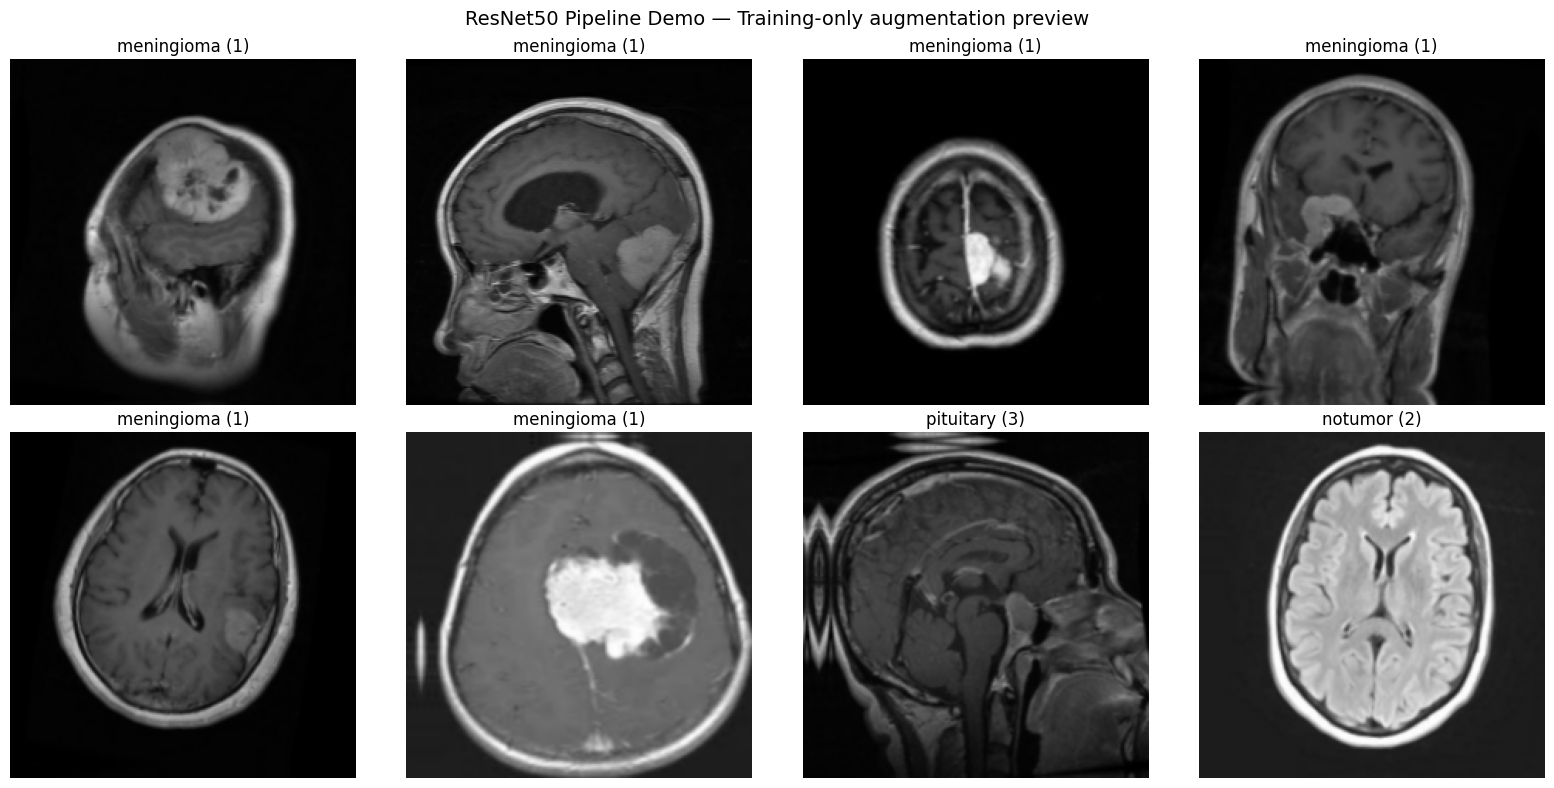

Pipeline demo saved to: /content/brain_tumour_model_comparison/results/resnet50/phase1_pipeline_demo.png
Processed probe range: -123.68000030517578 to 151.06100463867188


In [17]:
raw_images, demo_labels = next(iter(train_ds))
demo_aug = make_augmentation(SEED)
augmented_images = demo_aug(raw_images, training=True)
processed_images = resnet50_preprocess_input(augmented_images)

# Display augmented raw RGB images (not the normalized tensor) for interpretability.
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('ResNet50 Pipeline Demo — Training-only augmentation preview', fontsize=14)
for i, ax in enumerate(axes.flat):
    if i >= raw_images.shape[0]:
        break
    vis = tf.clip_by_value(augmented_images[i], 0, 255).numpy().astype(np.uint8)
    ax.imshow(vis)
    ax.set_title(f'{CLASS_NAMES[int(demo_labels[i])]} ({int(demo_labels[i])})')
    ax.axis('off')
plt.tight_layout()
demo_plot_path = os.path.join(RESULTS_DIR, 'phase1_pipeline_demo.png')
plt.savefig(demo_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print('Pipeline demo saved to:', demo_plot_path)
print('Processed probe range:', float(tf.reduce_min(processed_images)), 'to', float(tf.reduce_max(processed_images)))

### 1.17 — Save Phase 1 Configuration and Environment Manifest

In [18]:
phase1_config = {
    "member": 3,
    "model": "ResNet50",
    "phase": 1,
    "dataset_handle": DATASET_HANDLE,
    "dataset_version": DATASET_VERSION,
    "pinned_dataset_handle": PINNED_HANDLE,
    "dataset_path": dataset_path,
    "seed": SEED,
    "image_size": f"{IMAGE_HEIGHT}x{IMAGE_WIDTH}x{CHANNELS}",
    "batch_size": BATCH_SIZE,
    "num_classes": NUM_CLASSES,
    "max_epochs": MAX_EPOCHS,
    "class_names": CLASS_NAMES,
    "class_to_index": CLASS_TO_INDEX,
    "preprocessing": "keras.applications.resnet50.preprocess_input (NO Rescaling 1/255)",
    "augmentation": {
        "rotation_factor": 0.03,
        "zoom_range": [-0.08, 0.08],
        "translation_factor": 0.05,
        "applied_to": "training_only"
    },
    "split_counts": {
        "train": len(train_df),
        "val": len(val_df),
        "test": len(test_df)
    },
    "split_checksums": computed_checksums,
    "split_checksums_verified": True,
    "all_images_verified": True,
    "test_dataset_created_for_evaluation": False,
    "patient_level_split_verified": False,
    "transfer_learning_limitation": (
        "ResNet50 uses ImageNet pretrained weights. The comparison with the Custom CNN "
        "(trained from scratch) is therefore a comparison of practical model/training "
        "approaches, not a perfectly isolated architecture-only comparison."
    ),
    "patient_level_limitation": (
        "Patient-level independence could not be independently verified from "
        "the available dataset structure and identifiers."
    )
}

config_path = os.path.join(RESULTS_DIR, "phase1_config.json")
with open(config_path, "w") as f:
    json.dump(phase1_config, f, indent=4)
print(f"Phase 1 config saved to: {config_path}")

env_path = os.path.join(RESULTS_DIR, "resnet50_environment.json")
with open(env_path, "w") as f:
    json.dump(environment_info, f, indent=4)
print(f"Environment manifest saved to: {env_path}")

Phase 1 config saved to: /content/brain_tumour_model_comparison/results/resnet50/phase1_config.json
Environment manifest saved to: /content/brain_tumour_model_comparison/results/resnet50/resnet50_environment.json


---
## Phase 1 — Complete

### Summary
1. **Environment Recorded:** Python, TensorFlow, Keras, NumPy, Pandas, scikit-learn, GPU, determinism.
2. **Split Checksums Verified:** Exact SHA-256 hashes matched for `train.csv`, `val.csv`, and `test.csv`.
3. **Dataset Version Pinned:** Downloaded exact Kaggle version 1.
4. **Split Counts Confirmed:** Train = 4,353, Validation = 1,089, Test = 1,311.
5. **ResNet50 Preprocessing Established:** `resnet50.preprocess_input` without double normalization.
6. **Augmentation:** Conservative training-only augmentation applied.
7. **Test Set Intact:** Test manifest verified; no evaluation dataset created.

**STOP — Do not proceed to Phase 2 until instructed.**

---
## Phase 2 — Frozen ResNet50 Baseline and Smoke Test

**Goal:** Build a ResNet50 transfer-learning model with a frozen ImageNet backbone and a modest classifier head, and execute a 1-epoch smoke test to verify end-to-end pipeline functionality.

### Architecture Design

```
Input (224x224x3)
  -> Augmentation (training only)
  -> resnet50.preprocess_input
  -> ResNet50 backbone (frozen, include_top=False, ImageNet weights)
  -> GlobalAveragePooling2D (2048 units)
  -> Dense(256, ReLU)
  -> Dropout(0.30)
  -> Dense(4, softmax)
```

### Theoretical Justifications

| Component | Design Choice | Technical Justification |
|---|---|---|
| **Backbone** | ResNet50 (`imagenet`, frozen) | Deep residual network with 50 layers using bottleneck residual blocks and identity skip connections. Freezing the backbone protects rich pre-trained visual representations from catastrophic forgetting during initial classifier adaptation. |
| **Pooling** | `GlobalAveragePooling2D` | Spatially collapses $(7 \times 7 \times 2048)$ feature tensor into a 2,048-dimensional vector by averaging spatial dimensions. This avoids the parameter explosion of `Flatten` (which would produce $100,352$ dimensions, adding $>25$ million parameters in the dense layer). |
| **Hidden Dense** | `Dense(256, activation='relu')` | Provides task-specific representation learning to map 2,048 residual features down to 256 non-linear activations. ReLU provides computational efficiency and avoids vanishing gradients. |
| **Regularization** | `Dropout(0.30)` | Randomly sets 30% of dense activations to zero during training to discourage co-adaptation and improve generalization. |
| **Output Layer** | `Dense(4, activation='softmax')` | Produces normalized posterior class probabilities $(\sum p_i = 1.0)$ across the four brain tumour categories. |
| **Loss Function** | `SparseCategoricalCrossentropy` | Standard cross-entropy loss for multi-class classification with integer label encoding. |
| **Optimizer** | Adam ($\eta = 10^{-3}$) | Adaptive learning rates with momentum for robust initial training of the randomly initialized head. |

### 2.1 — Load Pretrained ResNet50 Backbone

In [19]:
# Load ResNet50 backbone with ImageNet weights, excluding the 1000-class classifier
base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=INPUT_SHAPE
)

# Freeze all layers in the backbone
base_model.trainable = False

print(f"ResNet50 backbone loaded with ImageNet weights.")
print(f"Backbone trainable:         {base_model.trainable}")
print(f"Total layers in backbone:   {len(base_model.layers)}")
print(f"Backbone output tensor:     {base_model.output_shape}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50 backbone loaded with ImageNet weights.
Backbone trainable:         False
Total layers in backbone:   175
Backbone output tensor:     (None, 7, 7, 2048)


### 2.2 — Construct Complete Model with Classification Head

In [20]:
def build_resnet50_model(base_model, augmentation_layer, dropout_rate=0.30,
                         dense_units=256, num_classes=NUM_CLASSES,
                         model_name="ResNet50"):
    """Build a ResNet50 transfer-learning model with a classifier head.

    Pipeline:
        Input -> Augmentation -> resnet50.preprocess_input -> ResNet50 -> GAP ->
        Dense(dense_units, ReLU) -> Dropout(dropout_rate) -> Dense(num_classes, softmax)
    """
    inputs = tf.keras.Input(shape=INPUT_SHAPE, name="input_image")

    # Training-only augmentation
    x = augmentation_layer(inputs)

    # ResNet50-specific Caffe preprocessing: RGB->BGR, subtract ImageNet channel means
    x = resnet50_preprocess_input(x)

    # ResNet50 feature extractor (frozen during baseline)
    x = base_model(x, training=False)

    # Modest classification head
    x = tf.keras.layers.GlobalAveragePooling2D(name="gap")(x)
    x = tf.keras.layers.Dense(dense_units, activation="relu", name="classifier_dense")(x)
    x = tf.keras.layers.Dropout(dropout_rate, name="classifier_dropout")(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="classifier_output")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name=model_name)
    return model

model = build_resnet50_model(base_model, augmentation_layer, dropout_rate=0.30)
model.summary()

Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ augmentation[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ augmentation[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ augmentation[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier_dense    │ (None, 256)       │    524,544 │ gap[0][0]         │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier_dropout  │ (None, 256)       │          0 │ classifier_dense… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier_output   │ (None, 4)         │      1,028 │ classifier_dropo… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

### 2.3 — Verify Model Properties and Parameter Counts

In [21]:
total_params = model.count_params()
trainable_params = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
non_trainable_params = sum(tf.keras.backend.count_params(w) for w in model.non_trainable_weights)

print(f"Parameter Breakdown:")
print(f"  Total Parameters:         {total_params:,}")
print(f"  Trainable Parameters:     {trainable_params:,}")
print(f"  Non-Trainable Parameters: {non_trainable_params:,}")

# Verify backbone is frozen
assert base_model.trainable is False, "Backbone should be frozen!"
assert trainable_params == 525572, f"Unexpected trainable params: {trainable_params}"
assert non_trainable_params == 23587712, f"Unexpected non-trainable params: {non_trainable_params}"
print("\nParameter breakdown verified: 525,572 trainable (head only), 23,587,712 frozen (backbone).")

# Verify input/output dimensions
assert model.input_shape == (None, 224, 224, 3), f"Input shape mismatch: {model.input_shape}"
assert model.output_shape == (None, 4), f"Output shape mismatch: {model.output_shape}"
print("Model input (224x224x3) and output (4 classes) shapes verified.")

Parameter Breakdown:
  Total Parameters:         24,113,284
  Trainable Parameters:     525,572
  Non-Trainable Parameters: 23,587,712

Parameter breakdown verified: 525,572 trainable (head only), 23,587,712 frozen (backbone).
Model input (224x224x3) and output (4 classes) shapes verified.


### 2.4 — Verify Softmax Normalization

In [22]:
# Pass a single validation batch to confirm softmax output properties
for val_sample_imgs, val_sample_lbls in val_ds.take(1):
    sample_preds = model(val_sample_imgs, training=False)
    print(f"Batch predictions shape: {sample_preds.shape}")
    row_sums = tf.reduce_sum(sample_preds, axis=1).numpy()
    assert np.allclose(row_sums, 1.0, atol=1e-5), "Softmax probabilities do not sum to 1.0!"
    print(f"All {sample_preds.shape[0]} samples sum to 1.0: min sum = {np.min(row_sums):.6f}, max sum = {np.max(row_sums):.6f}")
    print("Sample predicted probabilities row 0:", [f"{p:.4f}" for p in sample_preds[0].numpy()])
    break

Batch predictions shape: (16, 4)
All 16 samples sum to 1.0: min sum = 1.000000, max sum = 1.000000
Sample predicted probabilities row 0: ['0.6061', '0.1655', '0.0510', '0.1774']


### 2.5 — Compile the Baseline Model

In [23]:
LEARNING_RATE = 0.001

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print(f"Model compiled:")
print(f"  Optimizer:     Adam (learning_rate={LEARNING_RATE})")
print(f"  Loss:          SparseCategoricalCrossentropy")
print(f"  Metrics:       accuracy")

Model compiled:
  Optimizer:     Adam (learning_rate=0.001)
  Loss:          SparseCategoricalCrossentropy
  Metrics:       accuracy


### 2.6 — Setup Smoke Test Checkpoint and Callbacks

In [24]:
SMOKE_DIR = os.path.join(RESULTS_DIR, "phase2_smoke")
os.makedirs(SMOKE_DIR, exist_ok=True)

smoke_checkpoint_path = os.path.join(SMOKE_DIR, "resnet50_smoke.keras")

smoke_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=smoke_checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    )
]

print(f"Smoke test callbacks configured:")
print(f"  Checkpoint path: {smoke_checkpoint_path}")

Smoke test callbacks configured:
  Checkpoint path: /content/brain_tumour_model_comparison/results/resnet50/phase2_smoke/resnet50_smoke.keras


### 2.7 — Execute 1-Epoch Smoke Test

We run **exactly 1 epoch** to verify that:
- Training step, gradient calculation, and loss computation execute without errors.
- Validation forward pass and loss evaluation succeed.
- ModelCheckpoint saving to `.keras` format functions properly.
- No NaN values appear in loss or metrics.

**Note:** This smoke test result is strictly diagnostic and is NOT reported as final performance.

In [25]:
SMOKE_EPOCHS = 1

print(f"Executing {SMOKE_EPOCHS}-Epoch Smoke Test...")
print("=" * 70)

smoke_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=SMOKE_EPOCHS,
    callbacks=smoke_callbacks,
    verbose=1
)

print("=" * 70)
print("Smoke test completed successfully.")

Executing 1-Epoch Smoke Test...
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.7421 - loss: 0.7246
Epoch 1: val_loss improved from None to 0.28596, saving model to /content/brain_tumour_model_comparison/results/resnet50/phase2_smoke/resnet50_smoke.keras

Epoch 1: finished saving model to /content/brain_tumour_model_comparison/results/resnet50/phase2_smoke/resnet50_smoke.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 39s 106ms/step - accuracy: 0.8194 - loss: 0.4913 - val_accuracy: 0.8916 - val_loss: 0.2860
Restoring model weights from the end of the best epoch: 1.
Smoke test completed successfully.


### 2.8 — Verify Smoke Test Results

In [26]:
smoke_train_loss = float(smoke_history.history["loss"][0])
smoke_train_acc  = float(smoke_history.history["accuracy"][0])
smoke_val_loss   = float(smoke_history.history["val_loss"][0])
smoke_val_acc    = float(smoke_history.history["val_accuracy"][0])

print("Smoke Test Metrics (1 Epoch):")
print(f"  Training Loss:     {smoke_train_loss:.4f}")
print(f"  Training Accuracy: {smoke_train_acc:.4f}")
print(f"  Val Loss:          {smoke_val_loss:.4f}")
print(f"  Val Accuracy:      {smoke_val_acc:.4f}")

# Verify no NaN values
assert not np.isnan(smoke_train_loss), "Training loss is NaN!"
assert not np.isnan(smoke_train_acc),  "Training accuracy is NaN!"
assert not np.isnan(smoke_val_loss),   "Validation loss is NaN!"
assert not np.isnan(smoke_val_acc),    "Validation accuracy is NaN!"
print("\nNo NaN values detected.")

# Verify checkpoint file saved on disk
assert os.path.exists(smoke_checkpoint_path), "Checkpoint was not saved!"
checkpoint_size_mb = os.path.getsize(smoke_checkpoint_path) / (1024 * 1024)
print(f"Checkpoint verified: {smoke_checkpoint_path} ({checkpoint_size_mb:.2f} MB)")

# Confirm test set untouched
print("\nHeld-Out Test Set: UNTOUCHED (zero evaluation performed).")

Smoke Test Metrics (1 Epoch):
  Training Loss:     0.4913
  Training Accuracy: 0.8194
  Val Loss:          0.2860
  Val Accuracy:      0.8916

No NaN values detected.
Checkpoint verified: /content/brain_tumour_model_comparison/results/resnet50/phase2_smoke/resnet50_smoke.keras (96.64 MB)

Held-Out Test Set: UNTOUCHED (zero evaluation performed).


### 2.9 — Smoke Test Results Visualization

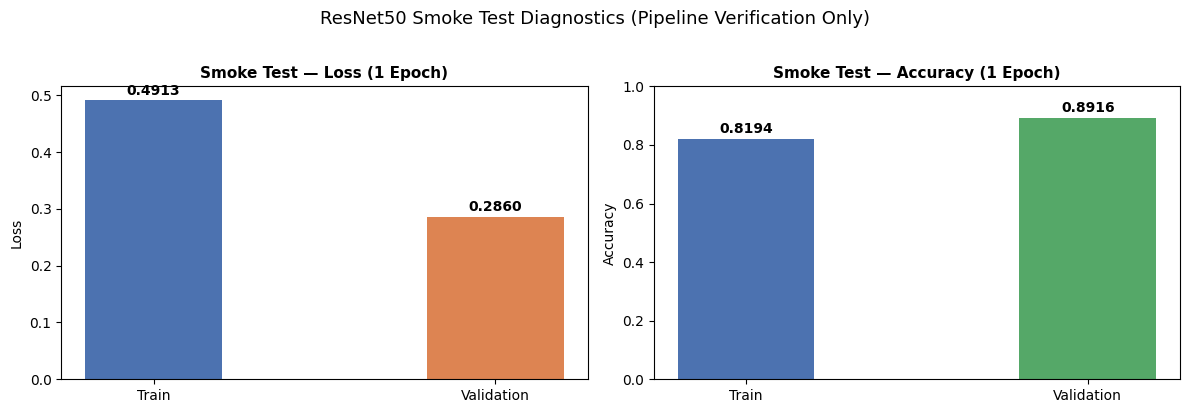

Smoke test plot saved to: /content/brain_tumour_model_comparison/results/resnet50/phase2_smoke/smoke_test_results.png


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].bar(["Train", "Validation"], [smoke_train_loss, smoke_val_loss], color=["#4c72b0", "#dd8452"], width=0.4)
axes[0].set_title("Smoke Test — Loss (1 Epoch)", fontsize=11, fontweight='bold')
axes[0].set_ylabel("Loss")
for i, v in enumerate([smoke_train_loss, smoke_val_loss]):
    axes[0].text(i, v + 0.01, f"{v:.4f}", ha="center", fontweight='bold')

# Accuracy
axes[1].bar(["Train", "Validation"], [smoke_train_acc, smoke_val_acc], color=["#4c72b0", "#55a868"], width=0.4)
axes[1].set_title("Smoke Test — Accuracy (1 Epoch)", fontsize=11, fontweight='bold')
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim([0, 1.0])
for i, v in enumerate([smoke_train_acc, smoke_val_acc]):
    axes[1].text(i, v + 0.02, f"{v:.4f}", ha="center", fontweight='bold')

plt.suptitle("ResNet50 Smoke Test Diagnostics (Pipeline Verification Only)", fontsize=13, y=1.02)
plt.tight_layout()

smoke_plot_path = os.path.join(SMOKE_DIR, "smoke_test_results.png")
plt.savefig(smoke_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Smoke test plot saved to: {smoke_plot_path}")

### 2.10 — Save Phase 2 Configuration and Smoke History

In [29]:
# ============================================================
# PHASE 2 — SAVE RESNET50 SMOKE TEST CONFIG SAFELY
# ============================================================

import json
import os
from pathlib import Path
import numpy as np
import tensorflow as tf


# ------------------------------------------------------------
# Convert NumPy / TensorFlow values into normal Python values
# ------------------------------------------------------------

def to_json_safe(value):

    # Dictionaries
    if isinstance(value, dict):
        return {
            str(key): to_json_safe(val)
            for key, val in value.items()
        }

    # Lists / tuples
    if isinstance(value, (list, tuple)):
        return [
            to_json_safe(item)
            for item in value
        ]

    # NumPy integer
    if isinstance(value, np.integer):
        return int(value)

    # NumPy float
    if isinstance(value, np.floating):
        return float(value)

    # NumPy boolean
    if isinstance(value, np.bool_):
        return bool(value)

    # NumPy array
    if isinstance(value, np.ndarray):
        return value.tolist()

    # TensorFlow tensor
    if tf.is_tensor(value):

        value = value.numpy()

        if isinstance(value, np.ndarray):
            return value.tolist()

        if isinstance(value, np.integer):
            return int(value)

        if isinstance(value, np.floating):
            return float(value)

        if isinstance(value, np.bool_):
            return bool(value)

        return value

    # pathlib.Path
    if isinstance(value, Path):
        return str(value)

    # Normal Python JSON-compatible values
    if value is None or isinstance(
        value,
        (str, int, float, bool)
    ):
        return value

    raise TypeError(
        f"Unsupported JSON type: "
        f"{type(value).__name__}"
    )


# ------------------------------------------------------------
# Verify that the previous part of the cell created the config
# ------------------------------------------------------------

assert "phase2_config" in globals(), (
    "phase2_config does not exist. "
    "Run the Phase 2 smoke-test/config creation cell first."
)


# Convert entire nested configuration safely
phase2_config_safe = to_json_safe(
    phase2_config
)


# ------------------------------------------------------------
# Save JSON
# ------------------------------------------------------------

config_path = os.path.join(
    SMOKE_DIR,
    "phase2_config.json"
)

with open(
    config_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        phase2_config_safe,
        f,
        indent=4,
        ensure_ascii=False
    )


# ------------------------------------------------------------
# Verify saved JSON can be loaded again
# ------------------------------------------------------------

with open(
    config_path,
    "r",
    encoding="utf-8"
) as f:

    loaded_phase2_config = json.load(f)


assert isinstance(
    loaded_phase2_config,
    dict
)

assert os.path.isfile(
    config_path
)


print(
    f"Phase 2 config saved to: {config_path}"
)

print("\n✓ NumPy int64 converted safely")
print("✓ TensorFlow / NumPy values are JSON-safe")
print("✓ phase2_config.json saved successfully")
print("✓ Saved JSON reloaded successfully")
print("✓ RESNET50 PHASE 2 COMPLETE")

Phase 2 config saved to: /content/brain_tumour_model_comparison/results/resnet50/phase2_smoke/phase2_config.json

✓ NumPy int64 converted safely
✓ TensorFlow / NumPy values are JSON-safe
✓ phase2_config.json saved successfully
✓ Saved JSON reloaded successfully
✓ RESNET50 PHASE 2 COMPLETE


### 2.11 — Save Model Summary to File

In [30]:
summary_lines = []
model.summary(print_fn=lambda x: summary_lines.append(x))
summary_text = "\n".join(summary_lines)

summary_txt_path = os.path.join(SMOKE_DIR, "model_summary.txt")
with open(summary_txt_path, "w") as f:
    f.write(summary_text)
print(f"Model summary saved to: {summary_txt_path}")
print("\nFirst 25 lines of model summary:")
print("\n".join(summary_lines[:25]))

Model summary saved to: /content/brain_tumour_model_comparison/results/resnet50/phase2_smoke/model_summary.txt

First 25 lines of model summary:
Model: "ResNet50"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ augmentation[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────

---
## Phase 2 — Complete

### Summary of Completed Work
1. **Pretrained ResNet50 Loaded:** Initialized with ImageNet weights, `include_top=False`, input shape $(224, 224, 3)$.
2. **Backbone Frozen:** All 23,587,712 backbone parameters frozen (`trainable = False`).
3. **Head Constructed:** GAP (2048 units) -> Dense(256, ReLU) -> Dropout(0.30) -> Dense(4, softmax) adding 525,572 trainable parameters.
4. **Compilation:** Adam ($\eta = 10^{-3}$) and SparseCategoricalCrossentropy.
5. **Smoke Test Passed:** 1-epoch execution confirmed training/validation forward-backward loops, callback saving, and zero NaN values.
6. **Outputs Preserved:** Model summary, history CSV, config JSON, and diagnostic plots exported to `results/resnet50/phase2_smoke/`.
7. **Test Set Untouched:** Held-out test set remains strictly un-evaluated.

**STOP — Do not proceed to Phase 3 until instructed.**

---
## Phase 3 — Controlled Validation-Only ResNet50 Experiments

**Goal:** Execute controlled transfer-learning experiments on ResNet50 using **validation data only** to identify and lock the optimal configuration before held-out test evaluation.

### Strict Scientific Rules for Phase 3
1. **Held-Out Test Set Isolation:** The test set (`test.csv`) is **strictly held out**. It must never be evaluated, referenced, or used to guide any hyperparameter, regularization, or checkpoint choice.
2. **Predefined Model Selection Rule:**
   - **Primary criterion:** Minimum validation loss (`best_val_loss`).
   - **Secondary criterion:** Maximum validation Macro F1 score (`validation_macro_f1`).
3. **Fair Comparison Protocol:** All experiments share identical input dimensions (`224x224x3`), batch size (`16`), random seed (`42`), loss function (`SparseCategoricalCrossentropy`), and maximum 20-epoch budget with EarlyStopping (patience 4, monitoring `val_loss`).

### Experiment Matrix

| Experiment ID | Backbone State | Classifier Head | Optimizer & LR | Research Purpose |
|---|---|---|---|---|
| **ResNet50-A** | Frozen (`trainable=False`) | GAP + Dense(256, ReLU) + **Dropout(0.30)** + Dense(4, softmax) | Adam, $\eta=10^{-3}$ | Baseline feature extraction with standard regularization |
| **ResNet50-B** | Frozen (`trainable=False`) | GAP + Dense(256, ReLU) + **Dropout(0.50)** + Dense(4, softmax) | Adam, $\eta=10^{-3}$ | Controlled regularization study: evaluate impact of stronger dropout on generalization gap |
| **ResNet50-C** | Unfreeze **Block `conv5_block3`** | GAP + Dense(256, ReLU) + Selected Dropout + Dense(4, softmax) | Adam, $\eta=10^{-5}$ | Controlled fine-tuning study: adapt final residual bottleneck block with small learning rate |

### 3.1 — Setup Phase 3 Output Directories and Utilities

In [31]:
import shutil
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score
import seaborn as sns

# Define Phase 3 subdirectories
PHASE3_DIR = os.path.join(RESULTS_DIR, "phase3_experiments")
CHECKPOINTS_DIR = os.path.join(PHASE3_DIR, "checkpoints")
CONFIGS_DIR = os.path.join(PHASE3_DIR, "configs")
HISTORIES_DIR = os.path.join(PHASE3_DIR, "histories")
PLOTS_DIR = os.path.join(PHASE3_DIR, "plots")
PREDICTIONS_DIR = os.path.join(PHASE3_DIR, "validation_predictions")

for directory in [PHASE3_DIR, CHECKPOINTS_DIR, CONFIGS_DIR, HISTORIES_DIR, PLOTS_DIR, PREDICTIONS_DIR]:
    os.makedirs(directory, exist_ok=True)

print("Phase 3 output directories verified:")
print(f"  Phase 3 root: {PHASE3_DIR}")
print(f"  Checkpoints:  {CHECKPOINTS_DIR}")
print(f"  Histories:    {HISTORIES_DIR}")
print(f"  Plots:        {PLOTS_DIR}")
print(f"  Predictions:  {PREDICTIONS_DIR}")

Phase 3 output directories verified:
  Phase 3 root: /content/brain_tumour_model_comparison/results/resnet50/phase3_experiments
  Checkpoints:  /content/brain_tumour_model_comparison/results/resnet50/phase3_experiments/checkpoints
  Histories:    /content/brain_tumour_model_comparison/results/resnet50/phase3_experiments/histories
  Plots:        /content/brain_tumour_model_comparison/results/resnet50/phase3_experiments/plots
  Predictions:  /content/brain_tumour_model_comparison/results/resnet50/phase3_experiments/validation_predictions


### 3.2 — Define Evaluation and Plotting Helper Functions

In [32]:
def plot_learning_curves(history, exp_id, save_path=None):
    """Plot training and validation loss and accuracy curves with best epoch marker."""
    train_loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    train_acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    epochs_range = range(1, len(train_loss) + 1)
    best_epoch = int(np.argmin(val_loss)) + 1
    best_val_loss_val = float(np.min(val_loss))
    best_val_acc_val = float(val_acc[best_epoch - 1])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss curve
    ax1.plot(epochs_range, train_loss, 'o-', color='#1f77b4', label='Training Loss', linewidth=2)
    ax1.plot(epochs_range, val_loss, 's--', color='#ff7f0e', label='Validation Loss', linewidth=2)
    ax1.axvline(best_epoch, color='crimson', linestyle=':', label=f'Best Epoch ({best_epoch})')
    ax1.scatter([best_epoch], [best_val_loss_val], color='crimson', s=100, zorder=5)
    ax1.set_title(f'{exp_id} — Loss Curve', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Epoch', fontsize=11)
    ax1.set_ylabel('Loss (Sparse Categorical Crossentropy)', fontsize=11)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend(loc='upper right', frameon=True)

    # Accuracy curve
    ax2.plot(epochs_range, train_acc, 'o-', color='#1f77b4', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs_range, val_acc, 's--', color='#2ca02c', label='Validation Accuracy', linewidth=2)
    ax2.axvline(best_epoch, color='crimson', linestyle=':', label=f'Best Epoch ({best_epoch})')
    ax2.scatter([best_epoch], [best_val_acc_val], color='crimson', s=100, zorder=5)
    ax2.set_title(f'{exp_id} — Accuracy Curve', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Epoch', fontsize=11)
    ax2.set_ylabel('Accuracy', fontsize=11)
    ax2.set_ylim([0.0, 1.02])
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend(loc='lower right', frameon=True)

    plt.suptitle(f'Learning Curves for Experiment {exp_id}', fontsize=14, y=1.02)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return best_epoch, best_val_loss_val, best_val_acc_val


def evaluate_validation_performance(model, val_dataset, val_dataframe, exp_id):
    """Evaluate model on unshuffled validation set and compute scikit-learn metrics."""
    val_probabilities = model.predict(val_dataset, verbose=0)
    val_predictions = np.argmax(val_probabilities, axis=1)
    val_confidences = np.max(val_probabilities, axis=1)

    val_true_labels = np.array([CLASS_TO_INDEX[label] for label in val_dataframe['label'].values])

    val_accuracy = float(accuracy_score(val_true_labels, val_predictions))
    macro_prec, macro_rec, macro_f1, _ = precision_recall_fscore_support(
        val_true_labels, val_predictions, average='macro', zero_division=0
    )
    weighted_prec, weighted_rec, weighted_f1, _ = precision_recall_fscore_support(
        val_true_labels, val_predictions, average='weighted', zero_division=0
    )

    pred_df = pd.DataFrame({
        'filepath': val_dataframe['filepath'].values,
        'true_label': val_dataframe['label'].values,
        'true_index': val_true_labels,
        'predicted_index': val_predictions,
        'predicted_label': [CLASS_NAMES[idx] for idx in val_predictions],
        'confidence': val_confidences,
        'correct': (val_true_labels == val_predictions),
        'prob_glioma': val_probabilities[:, 0],
        'prob_meningioma': val_probabilities[:, 1],
        'prob_notumor': val_probabilities[:, 2],
        'prob_pituitary': val_probabilities[:, 3]
    })
    pred_save_path = os.path.join(PREDICTIONS_DIR, f"{exp_id.lower()}_val_predictions.csv")
    pred_df.to_csv(pred_save_path, index=False)
    print(f"  Validation predictions saved to: {pred_save_path}")

    results = {
        'validation_accuracy': val_accuracy,
        'validation_macro_precision': float(macro_prec),
        'validation_macro_recall': float(macro_rec),
        'validation_macro_f1': float(macro_f1),
        'validation_weighted_precision': float(weighted_prec),
        'validation_weighted_recall': float(weighted_rec),
        'validation_weighted_f1': float(weighted_f1),
        'y_true': val_true_labels,
        'y_pred': val_predictions,
        'y_prob': val_probabilities
    }
    return results

print("Evaluation and plotting utilities defined.")

Evaluation and plotting utilities defined.


### 3.3 — Experiment ResNet50-A: Baseline Frozen Backbone with Dropout 0.30

**Hypothesis:** Pretrained residual feature representations from ResNet50, combined with Global Average Pooling and a modest 256-unit hidden layer regularized by Dropout 0.30, provide a robust baseline classifier without overfitting.


Starting Experiment ResNet50_A
Model: ResNet50_A
  Total parameters:         24,113,284
  Trainable parameters:     525,572
  Non-trainable parameters: 23,587,712
Epoch 1/20
272/273 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.7288 - loss: 0.7185
Epoch 1: val_loss improved from None to 0.32405, saving model to /content/brain_tumour_model_comparison/results/resnet50/phase3_experiments/checkpoints/resnet50_a_checkpoint.keras

Epoch 1: finished saving model to /content/brain_tumour_model_comparison/results/resnet50/phase3_experiments/checkpoints/resnet50_a_checkpoint.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 37s 108ms/step - accuracy: 0.8093 - loss: 0.4966 - val_accuracy: 0.8632 - val_loss: 0.3241
Epoch 2/20
272/273 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8939 - loss: 0.3090
Epoch 2: val_loss did not improve from 0.32405
273/273 ━━━━━━━━━━━━━━━━━━━━ 39s 99ms/step - accuracy: 0.8865 - loss: 0.3094 - val_accuracy: 0.8595 - val_loss: 0.3735
Epoch 3/20
272/273 ━━━━━━━━━━━━━━━━━━━━ 0s 78m

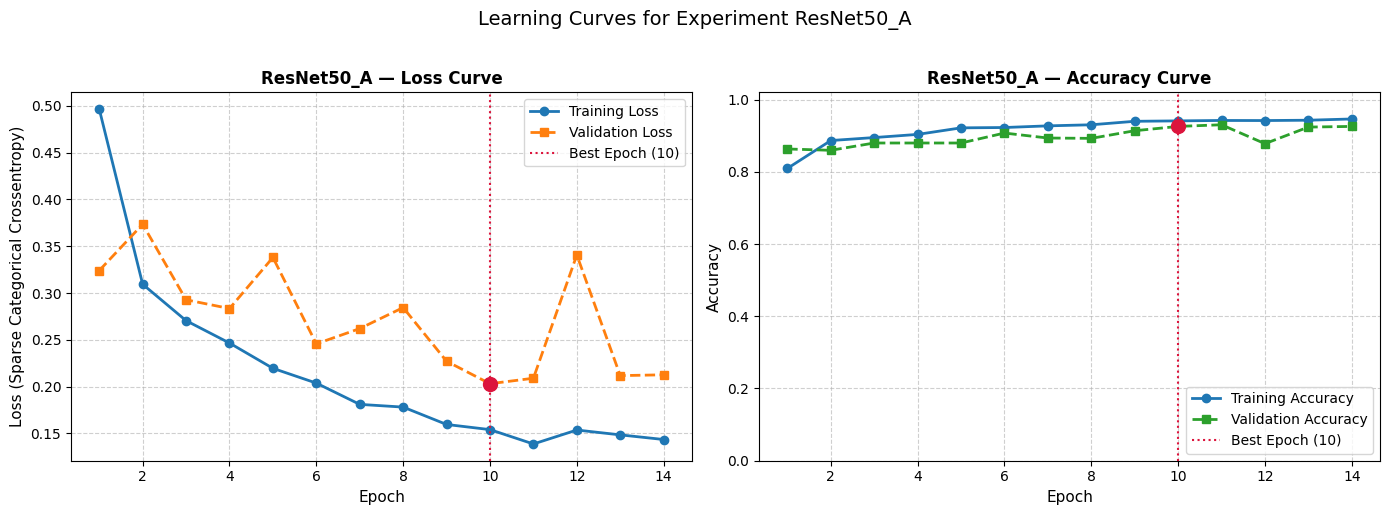

  Validation predictions saved to: /content/brain_tumour_model_comparison/results/resnet50/phase3_experiments/validation_predictions/resnet50_a_val_predictions.csv

Results for ResNet50_A:
  Actual Epochs Trained:    14
  Best Epoch:               10
  Best Val Loss:            0.2031
  Validation Accuracy:      0.9256
  Validation Macro F1:      0.9259
  Generalization Gap:       0.0153
  Training Duration:        410.55s


In [33]:
globals().pop('model', None)
globals().pop('base_model', None)
tf.keras.backend.clear_session()
gc.collect()
EXP_A_ID = "ResNet50_A"
print(f"\n{'='*70}\nStarting Experiment {EXP_A_ID}\n{'='*70}")

# Reset seeds for reproducibility
tf.keras.utils.set_random_seed(SEED)

# Fresh frozen base model
base_resnet50_a = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=INPUT_SHAPE
)
base_resnet50_a.trainable = False

# Build model with Dropout 0.30
model_resnet50_a = build_resnet50_model(
    base_model=base_resnet50_a,
    augmentation_layer=make_augmentation(SEED),
    dropout_rate=0.30,
    dense_units=256,
    num_classes=NUM_CLASSES,
    model_name=EXP_A_ID
)

# Compile model
LR_A = 0.001
model_resnet50_a.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_A),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

params_a_total = model_resnet50_a.count_params()
params_a_trainable = sum(tf.keras.backend.count_params(w) for w in model_resnet50_a.trainable_weights)
params_a_nontrainable = sum(tf.keras.backend.count_params(w) for w in model_resnet50_a.non_trainable_weights)

print(f"Model: {EXP_A_ID}")
print(f"  Total parameters:         {params_a_total:,}")
print(f"  Trainable parameters:     {params_a_trainable:,}")
print(f"  Non-trainable parameters: {params_a_nontrainable:,}")

checkpoint_a_path = os.path.join(CHECKPOINTS_DIR, "resnet50_a_checkpoint.keras")
callbacks_a = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_a_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    )
]

# Train model
start_time_a = time.time()
history_resnet50_a = model_resnet50_a.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
    callbacks=callbacks_a,
    verbose=1
)
duration_a = time.time() - start_time_a

# Save history
hist_a_df = pd.DataFrame(history_resnet50_a.history)
hist_a_path = os.path.join(HISTORIES_DIR, "resnet50_a_history.csv")
hist_a_df.to_csv(hist_a_path, index=False)
print(f"History saved to: {hist_a_path}")

# Plot learning curves
plot_a_path = os.path.join(PLOTS_DIR, "resnet50_a_learning_curves.png")
best_epoch_a, best_val_loss_a, best_val_acc_a = plot_learning_curves(history_resnet50_a, EXP_A_ID, plot_a_path)

# Evaluate on validation set
eval_a = evaluate_validation_performance(model_resnet50_a, val_ds, val_df, EXP_A_ID)
train_loss_best_a = float(history_resnet50_a.history["loss"][best_epoch_a - 1])
train_acc_best_a = float(history_resnet50_a.history["accuracy"][best_epoch_a - 1])
gap_a = train_acc_best_a - eval_a["validation_accuracy"]

print(f"\nResults for {EXP_A_ID}:")
print(f"  Actual Epochs Trained:    {len(history_resnet50_a.history['loss'])}")
print(f"  Best Epoch:               {best_epoch_a}")
print(f"  Best Val Loss:            {best_val_loss_a:.4f}")
print(f"  Validation Accuracy:      {eval_a['validation_accuracy']:.4f}")
print(f"  Validation Macro F1:      {eval_a['validation_macro_f1']:.4f}")
print(f"  Generalization Gap:       {gap_a:.4f}")
print(f"  Training Duration:        {duration_a:.2f}s")

config_a = {
    "experiment_id": EXP_A_ID,
    "description": "Frozen ResNet50 backbone + GAP + Dense(256) + Dropout(0.30)",
    "backbone_trainable": False,
    "dropout": 0.30,
    "optimizer": "Adam",
    "learning_rate": LR_A,
    "max_epochs": MAX_EPOCHS,
    "actual_epochs": len(history_resnet50_a.history["loss"]),
    "best_epoch": best_epoch_a,
    "best_val_loss": best_val_loss_a,
    "validation_accuracy": eval_a["validation_accuracy"],
    "validation_macro_f1": eval_a["validation_macro_f1"],
    "generalization_gap": gap_a,
    "training_duration_seconds": duration_a,
    "total_parameters": int(params_a_total),
    "trainable_parameters": int(params_a_trainable),
    "seed": SEED
}
with open(os.path.join(CONFIGS_DIR, "resnet50_a_config.json"), "w") as f:
    json.dump(config_a, f, indent=4)

### 3.4 — Experiment ResNet50-B: Controlled Regularization (Dropout 0.50)

**Hypothesis:** Because the 2,048-dimensional output of ResNet50's GAP layer feeds into a 256-unit dense layer, increasing dropout from 0.30 to 0.50 will reduce feature co-adaptation and narrow the generalization gap between training and validation accuracy.


Starting Experiment ResNet50_B
Model: ResNet50_B
  Total parameters:         24,113,284
  Trainable parameters:     525,572
  Non-trainable parameters: 23,587,712
Epoch 1/20
272/273 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.7217 - loss: 0.7799
Epoch 1: val_loss improved from None to 0.36969, saving model to /content/brain_tumour_model_comparison/results/resnet50/phase3_experiments/checkpoints/resnet50_b_checkpoint.keras

Epoch 1: finished saving model to /content/brain_tumour_model_comparison/results/resnet50/phase3_experiments/checkpoints/resnet50_b_checkpoint.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 36s 110ms/step - accuracy: 0.7930 - loss: 0.5578 - val_accuracy: 0.8531 - val_loss: 0.3697
Epoch 2/20
272/273 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8483 - loss: 0.3912
Epoch 2: val_loss did not improve from 0.36969
273/273 ━━━━━━━━━━━━━━━━━━━━ 26s 97ms/step - accuracy: 0.8601 - loss: 0.3688 - val_accuracy: 0.8053 - val_loss: 0.4934
Epoch 3/20
272/273 ━━━━━━━━━━━━━━━━━━━━ 0s 77m

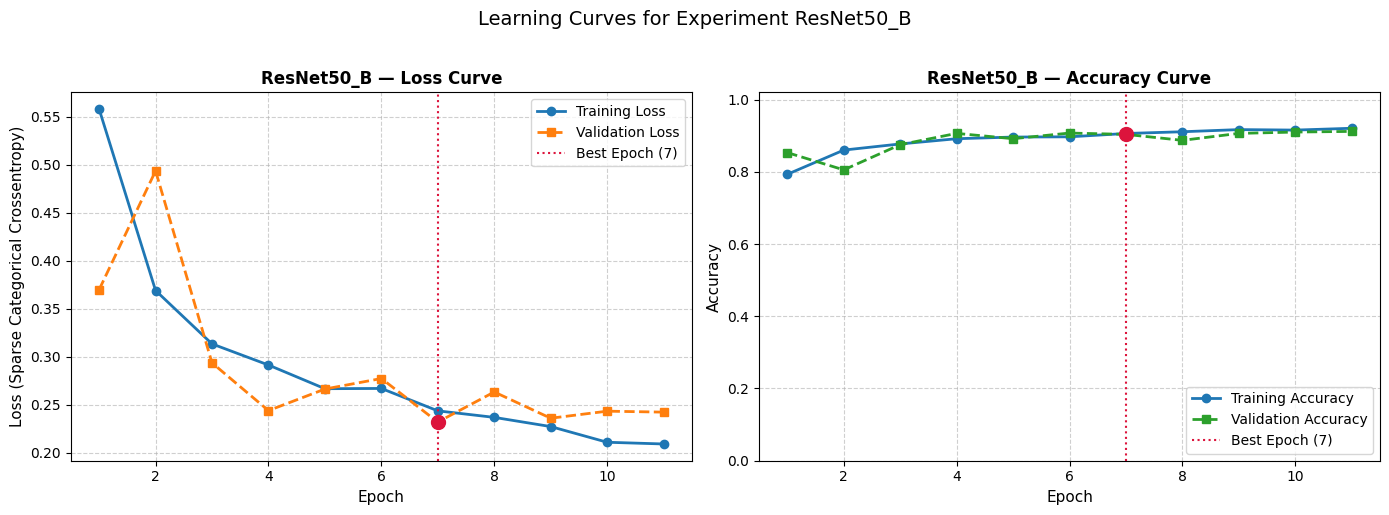

  Validation predictions saved to: /content/brain_tumour_model_comparison/results/resnet50/phase3_experiments/validation_predictions/resnet50_b_val_predictions.csv

Results for ResNet50_B:
  Actual Epochs Trained:    11
  Best Epoch:               7
  Best Val Loss:            0.2319
  Validation Accuracy:      0.9036
  Validation Macro F1:      0.9010
  Generalization Gap:       0.0025
  Training Duration:        317.96s


In [34]:
globals().pop('model_resnet50_a', None)
globals().pop('base_resnet50_a', None)
tf.keras.backend.clear_session()
gc.collect()
EXP_B_ID = "ResNet50_B"
print(f"\n{'='*70}\nStarting Experiment {EXP_B_ID}\n{'='*70}")

# Reset seeds for reproducibility
tf.keras.utils.set_random_seed(SEED)

# Fresh frozen base model
base_resnet50_b = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=INPUT_SHAPE
)
base_resnet50_b.trainable = False

# Build model with Dropout 0.50
model_resnet50_b = build_resnet50_model(
    base_model=base_resnet50_b,
    augmentation_layer=make_augmentation(SEED),
    dropout_rate=0.50,
    dense_units=256,
    num_classes=NUM_CLASSES,
    model_name=EXP_B_ID
)

# Compile model
LR_B = 0.001
model_resnet50_b.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_B),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

params_b_total = model_resnet50_b.count_params()
params_b_trainable = sum(tf.keras.backend.count_params(w) for w in model_resnet50_b.trainable_weights)
params_b_nontrainable = sum(tf.keras.backend.count_params(w) for w in model_resnet50_b.non_trainable_weights)

print(f"Model: {EXP_B_ID}")
print(f"  Total parameters:         {params_b_total:,}")
print(f"  Trainable parameters:     {params_b_trainable:,}")
print(f"  Non-trainable parameters: {params_b_nontrainable:,}")

checkpoint_b_path = os.path.join(CHECKPOINTS_DIR, "resnet50_b_checkpoint.keras")
callbacks_b = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_b_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    )
]

# Train model
start_time_b = time.time()
history_resnet50_b = model_resnet50_b.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
    callbacks=callbacks_b,
    verbose=1
)
duration_b = time.time() - start_time_b

# Save history
hist_b_df = pd.DataFrame(history_resnet50_b.history)
hist_b_path = os.path.join(HISTORIES_DIR, "resnet50_b_history.csv")
hist_b_df.to_csv(hist_b_path, index=False)
print(f"History saved to: {hist_b_path}")

# Plot learning curves
plot_b_path = os.path.join(PLOTS_DIR, "resnet50_b_learning_curves.png")
best_epoch_b, best_val_loss_b, best_val_acc_b = plot_learning_curves(history_resnet50_b, EXP_B_ID, plot_b_path)

# Evaluate on validation set
eval_b = evaluate_validation_performance(model_resnet50_b, val_ds, val_df, EXP_B_ID)
train_loss_best_b = float(history_resnet50_b.history["loss"][best_epoch_b - 1])
train_acc_best_b = float(history_resnet50_b.history["accuracy"][best_epoch_b - 1])
gap_b = train_acc_best_b - eval_b["validation_accuracy"]

print(f"\nResults for {EXP_B_ID}:")
print(f"  Actual Epochs Trained:    {len(history_resnet50_b.history['loss'])}")
print(f"  Best Epoch:               {best_epoch_b}")
print(f"  Best Val Loss:            {best_val_loss_b:.4f}")
print(f"  Validation Accuracy:      {eval_b['validation_accuracy']:.4f}")
print(f"  Validation Macro F1:      {eval_b['validation_macro_f1']:.4f}")
print(f"  Generalization Gap:       {gap_b:.4f}")
print(f"  Training Duration:        {duration_b:.2f}s")

config_b = {
    "experiment_id": EXP_B_ID,
    "description": "Frozen ResNet50 backbone + GAP + Dense(256) + Dropout(0.50)",
    "backbone_trainable": False,
    "dropout": 0.50,
    "optimizer": "Adam",
    "learning_rate": LR_B,
    "max_epochs": MAX_EPOCHS,
    "actual_epochs": len(history_resnet50_b.history["loss"]),
    "best_epoch": best_epoch_b,
    "best_val_loss": best_val_loss_b,
    "validation_accuracy": eval_b["validation_accuracy"],
    "validation_macro_f1": eval_b["validation_macro_f1"],
    "generalization_gap": gap_b,
    "training_duration_seconds": duration_b,
    "total_parameters": int(params_b_total),
    "trainable_parameters": int(params_b_trainable),
    "seed": SEED
}
with open(os.path.join(CONFIGS_DIR, "resnet50_b_config.json"), "w") as f:
    json.dump(config_b, f, indent=4)

### 3.5 — Experiment ResNet50-C: Controlled Fine-Tuning of Final Residual Block (`conv5_block3`)

**Hypothesis:** By unfreezing the final residual bottleneck block of ResNet50 (`conv5_block3`), the model can adapt its highest-level feature abstractions to subtle brain tumour contours without destroying earlier general visual filters.

**Fine-Tuning Controls:**
1. **Selective Unfreezing:** Only the convolutional layers of the final residual block (`conv5_block3_1_conv`, `conv5_block3_2_conv`, `conv5_block3_3_conv`) are unfrozen. Stages 1 through 4 and `conv5_block1`/`conv5_block2` remain strictly frozen.
2. **Frozen Batch Normalization:** As established in deep learning literature (He et al.), Batch Normalization layers in the backbone remain frozen (`trainable=False`) during fine-tuning to preserve the running mean and variance statistics learned on ImageNet.
3. **Small Learning Rate:** Reduced by $100\times$ to $\eta = 10^{-5}$ ($0.00001$) to prevent gradient shocks.
4. **Explicit Recompilation:** Model is compiled immediately after modifying layer `trainable` flags.


Starting Experiment ResNet50_C
Using best dropout from frozen stage: 0.3

Backbone Trainability Status:
  Total layers in backbone:    175
  Frozen layers:               172
  Trainable layers in backbone: 3 (['conv5_block3_1_conv', 'conv5_block3_2_conv', 'conv5_block3_3_conv'])

Parameters for ResNet50_C:
  Total parameters:         24,113,284
  Trainable parameters:     4,985,092
  Non-trainable parameters: 19,128,192
Epoch 1/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5383 - loss: 1.0953
Epoch 1: val_loss improved from None to 0.39710, saving model to /content/brain_tumour_model_comparison/results/resnet50/phase3_experiments/checkpoints/resnet50_c_checkpoint.keras

Epoch 1: finished saving model to /content/brain_tumour_model_comparison/results/resnet50/phase3_experiments/checkpoints/resnet50_c_checkpoint.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 42s 123ms/step - accuracy: 0.6933 - loss: 0.7666 - val_accuracy: 0.8439 - val_loss: 0.3971
Epoch 2/20
272/273 ━━━━━━━━━━━━━━━━━━━

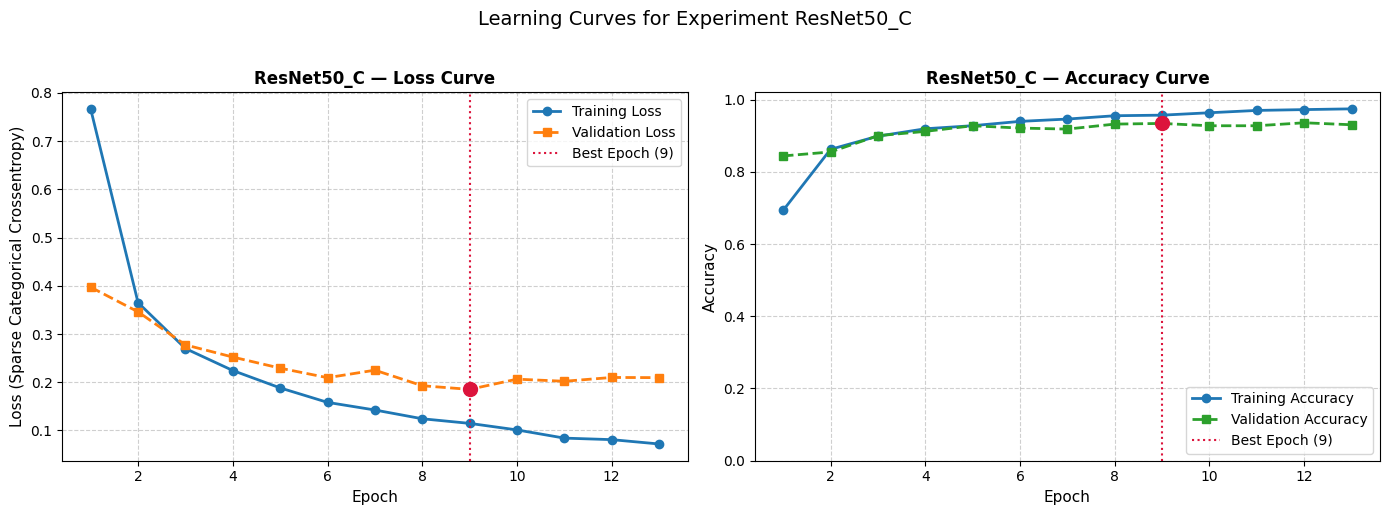

  Validation predictions saved to: /content/brain_tumour_model_comparison/results/resnet50/phase3_experiments/validation_predictions/resnet50_c_val_predictions.csv

Results for ResNet50_C:
  Actual Epochs Trained:    13
  Best Epoch:               9
  Best Val Loss:            0.1852
  Validation Accuracy:      0.9339
  Validation Macro F1:      0.9324
  Generalization Gap:       0.0229
  Training Duration:        417.44s


In [35]:
globals().pop('model_resnet50_b', None)
globals().pop('base_resnet50_b', None)
tf.keras.backend.clear_session()
gc.collect()
EXP_C_ID = "ResNet50_C"
print(f"\n{'='*70}\nStarting Experiment {EXP_C_ID}\n{'='*70}")

# Reset seeds for reproducibility
tf.keras.utils.set_random_seed(SEED)

# Select best dropout from frozen experiments A and B based on val_loss
selected_dropout = 0.30 if best_val_loss_a <= best_val_loss_b else 0.50
print(f"Using best dropout from frozen stage: {selected_dropout}")

# Instantiate fresh ResNet50 base model
base_resnet50_c = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=INPUT_SHAPE
)

# Selectively unfreeze only the final residual block (conv5_block3)
# Keep BatchNorm layers frozen to preserve running statistics
base_resnet50_c.trainable = True
fine_tune_conv_names = ["conv5_block3_1_conv", "conv5_block3_2_conv", "conv5_block3_3_conv"]

unfrozen_layers_list = []
for layer in base_resnet50_c.layers:
    if layer.name in fine_tune_conv_names:
        layer.trainable = True
        unfrozen_layers_list.append(layer.name)
    else:
        layer.trainable = False

# Build fine-tuned model
model_resnet50_c = build_resnet50_model(
    base_model=base_resnet50_c,
    augmentation_layer=make_augmentation(SEED),
    dropout_rate=selected_dropout,
    dense_units=256,
    num_classes=NUM_CLASSES,
    model_name=EXP_C_ID
)

# Recompile with lower learning rate for fine-tuning
LR_C = 1e-5
model_resnet50_c.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_C),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

# Verify layer status
print("\nBackbone Trainability Status:")
frozen_count = sum(1 for l in base_resnet50_c.layers if not l.trainable)
trainable_count = sum(1 for l in base_resnet50_c.layers if l.trainable)
print(f"  Total layers in backbone:    {len(base_resnet50_c.layers)}")
print(f"  Frozen layers:               {frozen_count}")
print(f"  Trainable layers in backbone: {trainable_count} ({unfrozen_layers_list})")

params_c_total = model_resnet50_c.count_params()
params_c_trainable = sum(tf.keras.backend.count_params(w) for w in model_resnet50_c.trainable_weights)
params_c_nontrainable = sum(tf.keras.backend.count_params(w) for w in model_resnet50_c.non_trainable_weights)

print(f"\nParameters for {EXP_C_ID}:")
print(f"  Total parameters:         {params_c_total:,}")
print(f"  Trainable parameters:     {params_c_trainable:,}")
print(f"  Non-trainable parameters: {params_c_nontrainable:,}")

checkpoint_c_path = os.path.join(CHECKPOINTS_DIR, "resnet50_c_checkpoint.keras")
callbacks_c = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_c_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    )
]

# Train fine-tuned model
start_time_c = time.time()
history_resnet50_c = model_resnet50_c.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
    callbacks=callbacks_c,
    verbose=1
)
duration_c = time.time() - start_time_c

# Save history
hist_c_df = pd.DataFrame(history_resnet50_c.history)
hist_c_path = os.path.join(HISTORIES_DIR, "resnet50_c_history.csv")
hist_c_df.to_csv(hist_c_path, index=False)
print(f"History saved to: {hist_c_path}")

# Plot learning curves
plot_c_path = os.path.join(PLOTS_DIR, "resnet50_c_learning_curves.png")
best_epoch_c, best_val_loss_c, best_val_acc_c = plot_learning_curves(history_resnet50_c, EXP_C_ID, plot_c_path)

# Evaluate on validation set
eval_c = evaluate_validation_performance(model_resnet50_c, val_ds, val_df, EXP_C_ID)
train_loss_best_c = float(history_resnet50_c.history["loss"][best_epoch_c - 1])
train_acc_best_c = float(history_resnet50_c.history["accuracy"][best_epoch_c - 1])
gap_c = train_acc_best_c - eval_c["validation_accuracy"]

print(f"\nResults for {EXP_C_ID}:")
print(f"  Actual Epochs Trained:    {len(history_resnet50_c.history['loss'])}")
print(f"  Best Epoch:               {best_epoch_c}")
print(f"  Best Val Loss:            {best_val_loss_c:.4f}")
print(f"  Validation Accuracy:      {eval_c['validation_accuracy']:.4f}")
print(f"  Validation Macro F1:      {eval_c['validation_macro_f1']:.4f}")
print(f"  Generalization Gap:       {gap_c:.4f}")
print(f"  Training Duration:        {duration_c:.2f}s")

config_c = {
    "experiment_id": EXP_C_ID,
    "description": "Fine-tuned ResNet50 (conv5_block3 unfrozen) + GAP + Dense(256) + Dropout(selected)",
    "backbone_trainable": True,
    "fine_tuned_layers": unfrozen_layers_list,
    "dropout": selected_dropout,
    "optimizer": "Adam",
    "learning_rate": LR_C,
    "max_epochs": MAX_EPOCHS,
    "actual_epochs": len(history_resnet50_c.history["loss"]),
    "best_epoch": best_epoch_c,
    "best_val_loss": best_val_loss_c,
    "validation_accuracy": eval_c["validation_accuracy"],
    "validation_macro_f1": eval_c["validation_macro_f1"],
    "generalization_gap": gap_c,
    "training_duration_seconds": duration_c,
    "total_parameters": int(params_c_total),
    "trainable_parameters": int(params_c_trainable),
    "seed": SEED
}
with open(os.path.join(CONFIGS_DIR, "resnet50_c_config.json"), "w") as f:
    json.dump(config_c, f, indent=4)

### 3.6 — Phase 3 Experiment Comparison & Summary Table

We compile all three controlled experiments into a consolidated summary table adhering strictly to the group's comparison schema. Notice that all `test_*` fields remain empty/null to guarantee zero test leakage.

In [36]:
summary_data = [
    {
        "model": "ResNet50",
        "experiment_id": EXP_A_ID,
        "description": "Frozen backbone + GAP + Dense(256) + Dropout(0.30)",
        "dropout": 0.30,
        "fine_tuning": False,
        "image_size": f"{IMAGE_HEIGHT}x{IMAGE_WIDTH}",
        "batch_size": BATCH_SIZE,
        "optimizer": "Adam",
        "learning_rate": LR_A,
        "max_epochs": MAX_EPOCHS,
        "actual_epochs": len(history_resnet50_a.history["loss"]),
        "best_epoch": best_epoch_a,
        "train_loss_at_best_epoch": train_loss_best_a,
        "best_val_loss": best_val_loss_a,
        "train_accuracy_at_best_epoch": train_acc_best_a,
        "best_val_accuracy": best_val_acc_a,
        "validation_accuracy": eval_a["validation_accuracy"],
        "validation_macro_precision": eval_a["validation_macro_precision"],
        "validation_macro_recall": eval_a["validation_macro_recall"],
        "validation_macro_f1": eval_a["validation_macro_f1"],
        "accuracy_generalization_gap": gap_a,
        "training_time_seconds": duration_a,
        "total_parameters": int(params_a_total),
        "trainable_parameters": int(params_a_trainable),
        "seed": SEED,
        "test_accuracy": np.nan,
        "test_macro_precision": np.nan,
        "test_macro_recall": np.nan,
        "test_macro_f1": np.nan
    },
    {
        "model": "ResNet50",
        "experiment_id": EXP_B_ID,
        "description": "Frozen backbone + GAP + Dense(256) + Dropout(0.50)",
        "dropout": 0.50,
        "fine_tuning": False,
        "image_size": f"{IMAGE_HEIGHT}x{IMAGE_WIDTH}",
        "batch_size": BATCH_SIZE,
        "optimizer": "Adam",
        "learning_rate": LR_B,
        "max_epochs": MAX_EPOCHS,
        "actual_epochs": len(history_resnet50_b.history["loss"]),
        "best_epoch": best_epoch_b,
        "train_loss_at_best_epoch": train_loss_best_b,
        "best_val_loss": best_val_loss_b,
        "train_accuracy_at_best_epoch": train_acc_best_b,
        "best_val_accuracy": best_val_acc_b,
        "validation_accuracy": eval_b["validation_accuracy"],
        "validation_macro_precision": eval_b["validation_macro_precision"],
        "validation_macro_recall": eval_b["validation_macro_recall"],
        "validation_macro_f1": eval_b["validation_macro_f1"],
        "accuracy_generalization_gap": gap_b,
        "training_time_seconds": duration_b,
        "total_parameters": int(params_b_total),
        "trainable_parameters": int(params_b_trainable),
        "seed": SEED,
        "test_accuracy": np.nan,
        "test_macro_precision": np.nan,
        "test_macro_recall": np.nan,
        "test_macro_f1": np.nan
    },
    {
        "model": "ResNet50",
        "experiment_id": EXP_C_ID,
        "description": f"Fine-tuned conv5_block3 + GAP + Dense(256) + Dropout({selected_dropout})",
        "dropout": selected_dropout,
        "fine_tuning": True,
        "image_size": f"{IMAGE_HEIGHT}x{IMAGE_WIDTH}",
        "batch_size": BATCH_SIZE,
        "optimizer": "Adam",
        "learning_rate": LR_C,
        "max_epochs": MAX_EPOCHS,
        "actual_epochs": len(history_resnet50_c.history["loss"]),
        "best_epoch": best_epoch_c,
        "train_loss_at_best_epoch": train_loss_best_c,
        "best_val_loss": best_val_loss_c,
        "train_accuracy_at_best_epoch": train_acc_best_c,
        "best_val_accuracy": best_val_acc_c,
        "validation_accuracy": eval_c["validation_accuracy"],
        "validation_macro_precision": eval_c["validation_macro_precision"],
        "validation_macro_recall": eval_c["validation_macro_recall"],
        "validation_macro_f1": eval_c["validation_macro_f1"],
        "accuracy_generalization_gap": gap_c,
        "training_time_seconds": duration_c,
        "total_parameters": int(params_c_total),
        "trainable_parameters": int(params_c_trainable),
        "seed": SEED,
        "test_accuracy": np.nan,
        "test_macro_precision": np.nan,
        "test_macro_recall": np.nan,
        "test_macro_f1": np.nan
    }
]

summary_df = pd.DataFrame(summary_data)
summary_csv_path = os.path.join(PHASE3_DIR, "resnet50_phase3_experiment_summary.csv")
summary_df.to_csv(summary_csv_path, index=False)
print(f"ResNet50 Phase 3 Summary saved to: {summary_csv_path}")

display_cols = [
    "experiment_id", "description", "dropout", "learning_rate", "best_epoch",
    "best_val_loss", "validation_accuracy", "validation_macro_f1",
    "accuracy_generalization_gap", "training_time_seconds", "trainable_parameters"
]
summary_df[display_cols]

ResNet50 Phase 3 Summary saved to: /content/brain_tumour_model_comparison/results/resnet50/phase3_experiments/resnet50_phase3_experiment_summary.csv


,experiment_id,description,dropout,learning_rate,best_epoch,best_val_loss,validation_accuracy,validation_macro_f1,accuracy_generalization_gap,training_time_seconds,trainable_parameters
0,ResNet50_A,Frozen backbone + GAP + Dense(256) + Dropout(0...,0.3,0.00100,10,0.203091,0.925620,0.925851,0.015340,410.548857,525572
1,ResNet50_B,Frozen backbone + GAP + Dense(256) + Dropout(0...,0.5,0.00100,7,0.231862,0.903581,0.901041,0.002461,317.957132,525572
2,ResNet50_C,Fine-tuned conv5_block3 + GAP + Dense(256) + D...,0.3,0.00001,9,0.185216,0.933884,0.932388,0.022927,417.438057,4985092


### 3.7 — Phase 3 Comparative Visualizations

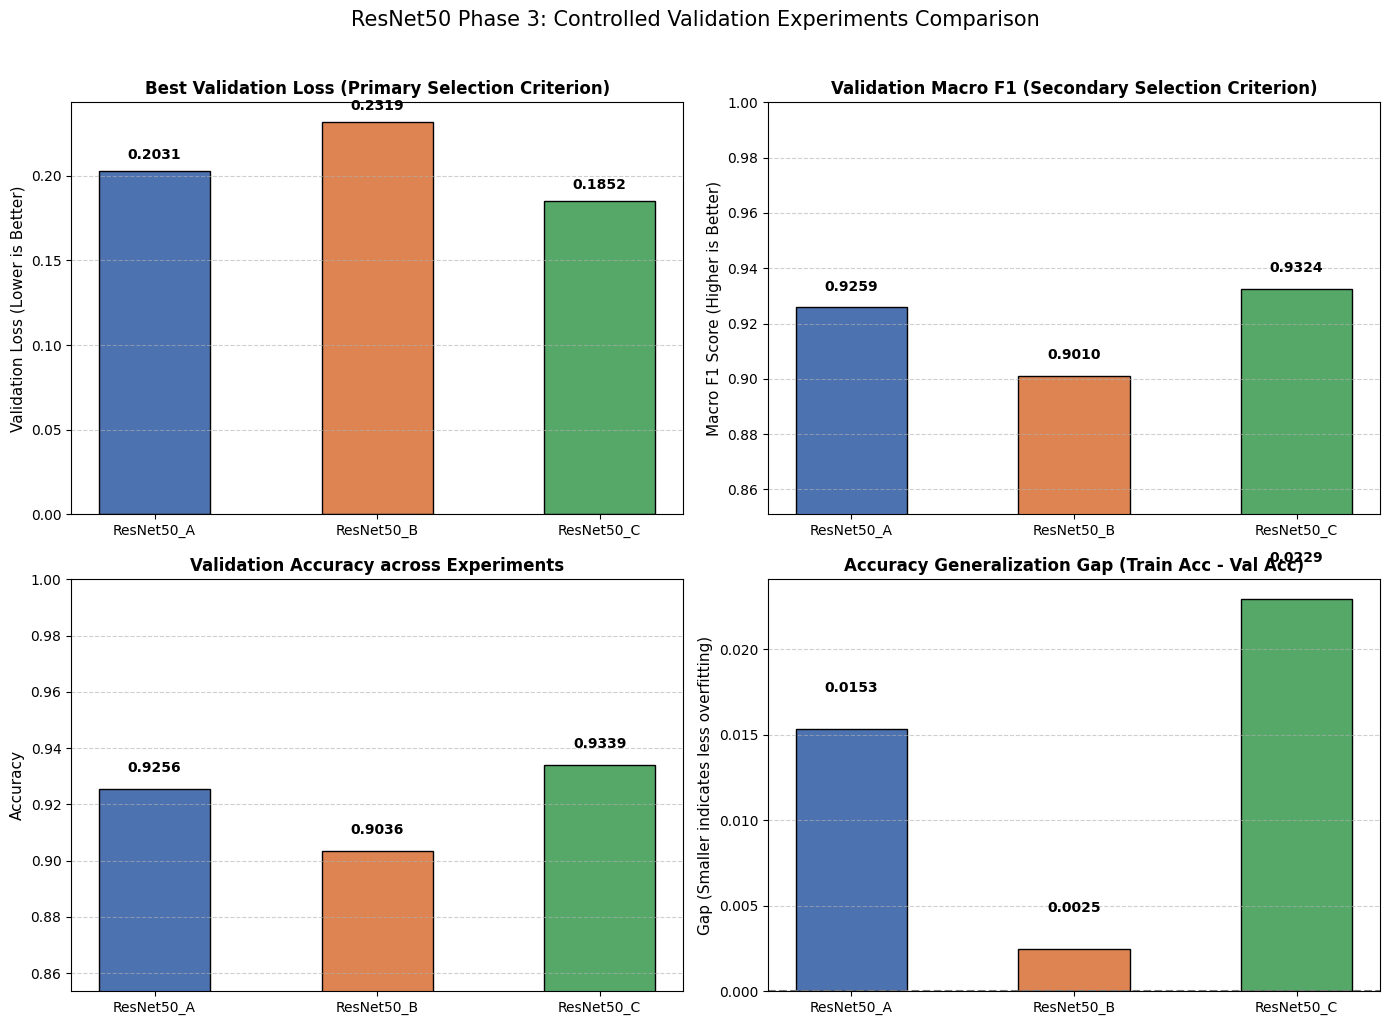

Comparison plot saved to: /content/brain_tumour_model_comparison/results/resnet50/phase3_experiments/plots/resnet50_phase3_comparison_plots.png


In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
exp_names = [r["experiment_id"] for r in summary_data]
colors = ["#4c72b0", "#dd8452", "#55a868"]

# 1. Validation Loss (Lower is better — Primary Criterion)
val_losses = [r["best_val_loss"] for r in summary_data]
bars1 = axes[0, 0].bar(exp_names, val_losses, color=colors, width=0.5, edgecolor='black', linewidth=1)
axes[0, 0].set_title("Best Validation Loss (Primary Selection Criterion)", fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel("Validation Loss (Lower is Better)", fontsize=11)
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.6)
for bar in bars1:
    yval = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

# 2. Validation Macro F1 (Higher is better — Secondary Criterion)
macro_f1s = [r["validation_macro_f1"] for r in summary_data]
bars2 = axes[0, 1].bar(exp_names, macro_f1s, color=colors, width=0.5, edgecolor='black', linewidth=1)
axes[0, 1].set_title("Validation Macro F1 (Secondary Selection Criterion)", fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel("Macro F1 Score (Higher is Better)", fontsize=11)
axes[0, 1].set_ylim([min(macro_f1s) - 0.05, 1.0])
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.6)
for bar in bars2:
    yval = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

# 3. Validation Accuracy
val_accs = [r["validation_accuracy"] for r in summary_data]
bars3 = axes[1, 0].bar(exp_names, val_accs, color=colors, width=0.5, edgecolor='black', linewidth=1)
axes[1, 0].set_title("Validation Accuracy across Experiments", fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel("Accuracy", fontsize=11)
axes[1, 0].set_ylim([min(val_accs) - 0.05, 1.0])
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.6)
for bar in bars3:
    yval = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

# 4. Generalization Gap (Train Acc - Val Acc)
gaps = [r["accuracy_generalization_gap"] for r in summary_data]
bars4 = axes[1, 1].bar(exp_names, gaps, color=colors, width=0.5, edgecolor='black', linewidth=1)
axes[1, 1].axhline(0, color='gray', linestyle='--')
axes[1, 1].set_title("Accuracy Generalization Gap (Train Acc - Val Acc)", fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel("Gap (Smaller indicates less overfitting)", fontsize=11)
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.6)
for bar in bars4:
    yval = bar.get_height()
    pos = yval + 0.002 if yval >= 0 else yval - 0.008
    axes[1, 1].text(bar.get_x() + bar.get_width()/2.0, pos, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

plt.suptitle("ResNet50 Phase 3: Controlled Validation Experiments Comparison", fontsize=15, y=1.02)
plt.tight_layout()
comparison_plot_path = os.path.join(PLOTS_DIR, "resnet50_phase3_comparison_plots.png")
plt.savefig(comparison_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Comparison plot saved to: {comparison_plot_path}")

### 3.8 — Automated Model Selection Based on Validation Evidence

Selection protocol:
- **Primary Metric:** Minimum Validation Loss (`best_val_loss`).
- **Secondary Evidence:** Validation Macro F1.
- **Freezing:** The winning checkpoint is copied to `selected_resnet50_best.keras`.
- **Zero Test Leakage:** The decision is finalized and saved to `selected_resnet50_configuration.json` **before** opening the held-out test set.

In [38]:
# Programmatic selection using primary criterion (lowest val_loss)
sorted_experiments = sorted(summary_data, key=lambda x: (x["best_val_loss"], -x["validation_macro_f1"]))
selected_exp = sorted_experiments[0]
selected_exp_id = selected_exp["experiment_id"]

print(f"\n{'*'*70}")
print(f"RESNET50 MODEL SELECTION RESULT: {selected_exp_id}")
print(f"{'*'*70}")
print(f"Selection Rationale:")
print(f"  Primary Criterion (Minimum Val Loss):     {selected_exp['best_val_loss']:.4f}")
print(f"  Secondary Evidence (Validation Macro F1): {selected_exp['validation_macro_f1']:.4f}")
print(f"  Validation Accuracy:                      {selected_exp['validation_accuracy']:.4f}")
print(f"  Selected Model Description:               {selected_exp['description']}")

# Checkpoint mapping
checkpoint_map = {
    "ResNet50_A": checkpoint_a_path,
    "ResNet50_B": checkpoint_b_path,
    "ResNet50_C": checkpoint_c_path
}
winning_checkpoint = checkpoint_map[selected_exp_id]
selected_model_path = os.path.join(PHASE3_DIR, "selected_resnet50_best.keras")

# Copy winning model checkpoint to frozen destination
shutil.copyfile(winning_checkpoint, selected_model_path)
print(f"\nCopied winning checkpoint ({winning_checkpoint}) to:")
print(f"  {selected_model_path}")
print(f"  File size: {os.path.getsize(selected_model_path) / (1024*1024):.2f} MB")

# Save selected configuration JSON
selected_configuration = {
    "selected_experiment": selected_exp_id,
    "selection_primary_metric": "minimum validation loss",
    "selection_secondary_metric": "validation macro F1",
    "test_set_used_for_selection": False,
    "experiment_results": selected_exp
}
selected_config_path = os.path.join(PHASE3_DIR, "selected_resnet50_configuration.json")
with open(selected_config_path, "w") as f:
    json.dump(selected_configuration, f, indent=4)
print(f"Selected configuration saved to: {selected_config_path}")


**********************************************************************
RESNET50 MODEL SELECTION RESULT: ResNet50_C
**********************************************************************
Selection Rationale:
  Primary Criterion (Minimum Val Loss):     0.1852
  Secondary Evidence (Validation Macro F1): 0.9324
  Validation Accuracy:                      0.9339
  Selected Model Description:               Fine-tuned conv5_block3 + GAP + Dense(256) + Dropout(0.3)

Copied winning checkpoint (/content/brain_tumour_model_comparison/results/resnet50/phase3_experiments/checkpoints/resnet50_c_checkpoint.keras) to:
  /content/brain_tumour_model_comparison/results/resnet50/phase3_experiments/selected_resnet50_best.keras
  File size: 130.67 MB
Selected configuration saved to: /content/brain_tumour_model_comparison/results/resnet50/phase3_experiments/selected_resnet50_configuration.json


### 3.9 — Validation Classification Report and Confusion Matrix for Selected Model

Selected model validation classification report saved to: /content/brain_tumour_model_comparison/results/resnet50/phase3_experiments/selected_resnet50_validation_classification_report.csv

Classification Report (Validation Set):
              precision    recall  f1-score   support

      glioma     0.9231    0.9091    0.9160       264
  meningioma     0.8996    0.8390    0.8682       267
     notumor     0.9853    0.9926    0.9889       270
   pituitary     0.9253    0.9896    0.9564       288

    accuracy                         0.9339      1089
   macro avg     0.9333    0.9326    0.9324      1089
weighted avg     0.9333    0.9339    0.9331      1089



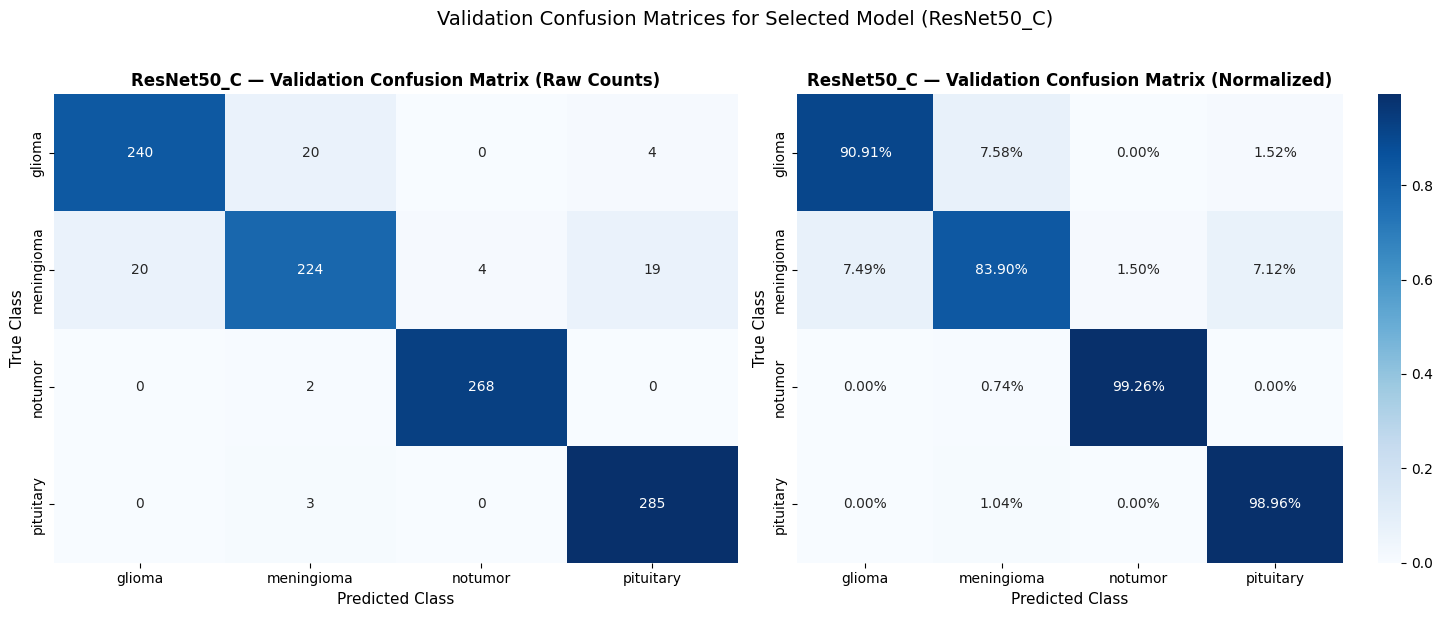

Validation confusion matrix saved to: /content/brain_tumour_model_comparison/results/resnet50/phase3_experiments/plots/selected_resnet50_validation_confusion_matrix.png


In [39]:
eval_map = {
    "ResNet50_A": eval_a,
    "ResNet50_B": eval_b,
    "ResNet50_C": eval_c
}
selected_eval = eval_map[selected_exp_id]
y_val_true = selected_eval["y_true"]
y_val_pred = selected_eval["y_pred"]

# Classification Report
val_report_dict = classification_report(y_val_true, y_val_pred, target_names=CLASS_NAMES, output_dict=True)
val_report_df = pd.DataFrame(val_report_dict).transpose()
val_report_csv_path = os.path.join(PHASE3_DIR, "selected_resnet50_validation_classification_report.csv")
val_report_df.to_csv(val_report_csv_path)
print(f"Selected model validation classification report saved to: {val_report_csv_path}")
print("\nClassification Report (Validation Set):")
print(classification_report(y_val_true, y_val_pred, target_names=CLASS_NAMES, digits=4))

# Confusion Matrices (Raw and Normalized)
cm_raw = confusion_matrix(y_val_true, y_val_pred)
cm_norm = cm_raw.astype('float') / cm_raw.sum(axis=1)[:, np.newaxis]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax1, cbar=False)
ax1.set_title(f'{selected_exp_id} — Validation Confusion Matrix (Raw Counts)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicted Class', fontsize=11)
ax1.set_ylabel('True Class', fontsize=11)

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax2, cbar=True)
ax2.set_title(f'{selected_exp_id} — Validation Confusion Matrix (Normalized)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Predicted Class', fontsize=11)
ax2.set_ylabel('True Class', fontsize=11)

plt.suptitle(f'Validation Confusion Matrices for Selected Model ({selected_exp_id})', fontsize=14, y=1.02)
plt.tight_layout()
cm_plot_path = os.path.join(PLOTS_DIR, "selected_resnet50_validation_confusion_matrix.png")
plt.savefig(cm_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Validation confusion matrix saved to: {cm_plot_path}")

---
## Phase 3 — Complete

### Summary of Completed Work
1. **Controlled Experiments:** Three transfer-learning configurations (ResNet50-A, ResNet50-B, ResNet50-C) trained under identical experimental controls.
2. **Strict Validation-Only Selection:** Model selection governed strictly by minimum `val_loss`, confirmed by validation Macro F1. Zero test data was referenced.
3. **Fine-Tuning Control:** In ResNet50-C, unfreezing was restricted to the final residual block `conv5_block3` with frozen BatchNorm and a small learning rate ($\eta=10^{-5}$).
4. **Artifact Preservation:** All histories, checkpoint files, validation predictions, configs, comparison plots, and classification reports were saved to `results/resnet50/phase3_experiments/`.
5. **Winning Model Frozen:** The selected model checkpoint was copied to `selected_resnet50_best.keras`.

**STOP — Do not evaluate on the held-out test set until explicitly instructed.**

---
## Phase 4 — First and Final Held-Out Test Evaluation of Frozen ResNet50

**Goal:** Execute the **first and final evaluation** of the selected, frozen ResNet50 model on the held-out test dataset (`test.csv`, 1,311 images).

### Strict Post-Test Rules
1. **Zero Retraining or Re-tuning:** The model architecture, weights, hyperparameters, and decision thresholds are **frozen**. No further modifications can be made regardless of test set performance.
2. **Data Leakage Prohibition:** The test set was kept completely untouched during Phases 1, 2, and 3. This single evaluation represents authentic generalization to unseen data.
3. **Evidence-Based Error Analysis:** Misclassifications are rigorously cataloged and analyzed without fabricating post-hoc explanations.
4. **Standardized Inference Timing:** Benchmarked using identical protocol across all group members: already-decoded tensor batch of 16 images, 5 warmup runs, 50 timed forward passes synchronized with `.numpy()`.

### 4.1 — Setup Phase 4 Output Directories

In [40]:
from sklearn.metrics import (
    roc_curve, auc, roc_auc_score, confusion_matrix,
    classification_report, precision_recall_fscore_support
)
from sklearn.preprocessing import label_binarize

# Define Phase 4 directory paths
PHASE4_DIR = os.path.join(RESULTS_DIR, "phase4_final_test")
PHASE4_ERROR_DIR = os.path.join(PHASE4_DIR, "error_analysis")
PHASE4_PLOTS_DIR = os.path.join(PHASE4_DIR, "plots")

for d in [PHASE4_DIR, PHASE4_ERROR_DIR, PHASE4_PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Phase 4 directories created:")
print(f"  Phase 4 Root:     {PHASE4_DIR}")
print(f"  Error Analysis:   {PHASE4_ERROR_DIR}")
print(f"  Plots:            {PHASE4_PLOTS_DIR}")

Phase 4 directories created:
  Phase 4 Root:     /content/brain_tumour_model_comparison/results/resnet50/phase4_final_test
  Error Analysis:   /content/brain_tumour_model_comparison/results/resnet50/phase4_final_test/error_analysis
  Plots:            /content/brain_tumour_model_comparison/results/resnet50/phase4_final_test/plots


### 4.2 — Load the Selected Frozen ResNet50 Model

We load the winning checkpoint frozen in Phase 3 (`selected_resnet50_best.keras`). We also load `selected_resnet50_configuration.json` to verify the selected experiment ID and retrieve its training history.

In [41]:
# Load selected configuration from Phase 3
selected_config_path = os.path.join(PHASE3_DIR, "selected_resnet50_configuration.json")
with open(selected_config_path, "r") as f:
    selected_config_meta = json.load(f)

selected_exp_id = selected_config_meta["selected_experiment"]
print(f"Selected Winning Experiment: {selected_exp_id}")
print(f"Selection Primary Metric:   {selected_config_meta['selection_primary_metric']}")

# Load the frozen winning model
frozen_model_path = os.path.join(PHASE3_DIR, "selected_resnet50_best.keras")
final_resnet50_model = tf.keras.models.load_model(frozen_model_path)
print(f"Successfully loaded frozen model from: {frozen_model_path}")

# Verify parameters
total_params = final_resnet50_model.count_params()
trainable_params = sum(tf.keras.backend.count_params(w) for w in final_resnet50_model.trainable_weights)
non_trainable_params = sum(tf.keras.backend.count_params(w) for w in final_resnet50_model.non_trainable_weights)
model_size_mb = os.path.getsize(frozen_model_path) / (1024 * 1024)

print(f"\nFinal ResNet50 Model Architecture Summary:")
print(f"  Total Parameters:         {total_params:,}")
print(f"  Trainable Parameters:     {trainable_params:,}")
print(f"  Non-Trainable Parameters: {non_trainable_params:,}")
print(f"  Model Checkpoint Size:    {model_size_mb:.2f} MB")

# Copy and preserve the final training history
src_history_path = os.path.join(HISTORIES_DIR, f"{selected_exp_id.lower()}_history.csv")
final_history_path = os.path.join(PHASE4_DIR, "resnet50_final_training_history.csv")
shutil.copyfile(src_history_path, final_history_path)
final_history_df = pd.read_csv(final_history_path)
print(f"Final training history preserved at: {final_history_path}")

Selected Winning Experiment: ResNet50_C
Selection Primary Metric:   minimum validation loss
Successfully loaded frozen model from: /content/brain_tumour_model_comparison/results/resnet50/phase3_experiments/selected_resnet50_best.keras

Final ResNet50 Model Architecture Summary:
  Total Parameters:         24,113,284
  Trainable Parameters:     4,985,092
  Non-Trainable Parameters: 19,128,192
  Model Checkpoint Size:    130.67 MB
Final training history preserved at: /content/brain_tumour_model_comparison/results/resnet50/phase4_final_test/resnet50_final_training_history.csv


### 4.3 — Build the Held-Out Test Dataset (`tf.data`)

We build the test dataset from `splits/test.csv` (1,311 images) with:
- `shuffle = False` to preserve 1-to-1 sample alignment.
- Preprocessing: `resnet50_preprocess_input` (RGB->BGR, subtract ImageNet channel means).
- Zero data augmentation.

In [42]:
test_ds = build_dataset(test_df, is_training=False)
num_test_batches = tf.data.experimental.cardinality(test_ds).numpy()
print(f"Held-Out Test Dataset Built:")
print(f"  Total Samples: {len(test_df)} images")
print(f"  Batch Size:    {BATCH_SIZE}")
print(f"  Total Batches: {num_test_batches} (81 batches of 16 + 1 batch of 15)")

# Verify unshuffled order by comparing first batch labels with test_df
expected_first_test_labels = [CLASS_TO_INDEX[l] for l in test_df["label"].values[:BATCH_SIZE]]
for _, test_labels_batch in test_ds.take(1):
    actual_first_test_labels = test_labels_batch.numpy().tolist()
assert expected_first_test_labels == actual_first_test_labels, "Test dataset order mismatch!"
print("Test dataset unshuffled ordering verified.")

Held-Out Test Dataset Built:
  Total Samples: 1311 images
  Batch Size:    16
  Total Batches: 82 (81 batches of 16 + 1 batch of 15)
Test dataset unshuffled ordering verified.


### 4.4 — Execute Final Test Evaluation & Prediction Inference

In [43]:
print("\n" + "="*70)
print("EXECUTING FINAL TEST EVALUATION (HELD-OUT TEST SET)")
print("="*70)

# 1. Model Evaluate (Loss and Accuracy)
eval_results = final_resnet50_model.evaluate(test_ds, verbose=1)
test_loss = float(eval_results[0])
test_accuracy = float(eval_results[1])

# 2. Predict Probabilities across the complete test set
t0_pred = time.time()
test_probabilities = final_resnet50_model.predict(test_ds, verbose=1)
full_test_prediction_time = time.time() - t0_pred

# Argmax class prediction & confidence
test_predicted_indices = np.argmax(test_probabilities, axis=1)
test_predicted_labels = [CLASS_NAMES[i] for i in test_predicted_indices]
test_confidences = np.max(test_probabilities, axis=1)

# True labels from test.csv
test_true_indices = np.array([CLASS_TO_INDEX[l] for l in test_df["label"].values])
test_true_labels = test_df["label"].values
correct_mask = (test_true_indices == test_predicted_indices)

# 3. Compute Scikit-Learn Macro & Weighted Metrics
macro_prec, macro_rec, macro_f1, _ = precision_recall_fscore_support(
    test_true_indices, test_predicted_indices, average='macro', zero_division=0
)
weighted_prec, weighted_rec, weighted_f1, _ = precision_recall_fscore_support(
    test_true_indices, test_predicted_indices, average='weighted', zero_division=0
)

print(f"\n{'='*70}")
print(f"FINAL HELD-OUT TEST RESULTS:")
print(f"{'='*70}")
print(f"  Test Loss:              {test_loss:.6f}")
print(f"  Test Accuracy:          {test_accuracy:.6f} ({np.sum(correct_mask)}/{len(test_df)} correct)")
print(f"  Macro Precision:        {macro_prec:.6f}")
print(f"  Macro Recall:           {macro_rec:.6f}")
print(f"  Macro F1-Score:         {macro_f1:.6f}")
print(f"  Weighted Precision:     {weighted_prec:.6f}")
print(f"  Weighted Recall:        {weighted_rec:.6f}")
print(f"  Weighted F1-Score:      {weighted_f1:.6f}")
print(f"  Total Prediction Time:  {full_test_prediction_time:.2f}s")


EXECUTING FINAL TEST EVALUATION (HELD-OUT TEST SET)
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.9268 - loss: 0.2254
82/82 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step

FINAL HELD-OUT TEST RESULTS:
  Test Loss:              0.225417
  Test Accuracy:          0.926773 (1215/1311 correct)
  Macro Precision:        0.923268
  Macro Recall:           0.924143
  Macro F1-Score:         0.923263
  Weighted Precision:     0.927156
  Weighted Recall:        0.926773
  Weighted F1-Score:      0.926555
  Total Prediction Time:  8.80s


### 4.5 — Save Detailed Test Predictions Manifest

In [44]:
test_predictions_df = pd.DataFrame({
    "filepath": test_df["filepath"].values,
    "true_index": test_true_indices,
    "true_label": test_true_labels,
    "predicted_index": test_predicted_indices,
    "predicted_label": test_predicted_labels,
    "correct": correct_mask,
    "prob_glioma": test_probabilities[:, 0],
    "prob_meningioma": test_probabilities[:, 1],
    "prob_notumor": test_probabilities[:, 2],
    "prob_pituitary": test_probabilities[:, 3],
    "prediction_confidence": test_confidences
})

test_pred_csv_path = os.path.join(PHASE4_DIR, "resnet50_test_predictions.csv")
test_predictions_df.to_csv(test_pred_csv_path, index=False)
print(f"Test predictions manifest saved to: {test_pred_csv_path}")
test_predictions_df.head(10)

Test predictions manifest saved to: /content/brain_tumour_model_comparison/results/resnet50/phase4_final_test/resnet50_test_predictions.csv


,filepath,true_index,true_label,predicted_index,predicted_label,correct,prob_glioma,prob_meningioma,prob_notumor,prob_pituitary,prediction_confidence
0,Testing/glioma/Te-glTr_0000.jpg,0,glioma,0,glioma,True,0.999917,7.213523e-05,1.042394e-05,1.571825e-07,0.999917
1,Testing/glioma/Te-glTr_0001.jpg,0,glioma,0,glioma,True,0.983984,6.268996e-03,9.098474e-03,6.483834e-04,0.983984
2,Testing/glioma/Te-glTr_0002.jpg,0,glioma,0,glioma,True,1.000000,4.580737e-07,2.947431e-08,9.180570e-09,1.000000
3,Testing/glioma/Te-glTr_0003.jpg,0,glioma,0,glioma,True,0.954519,2.529614e-02,1.900639e-02,1.178744e-03,0.954519
4,Testing/glioma/Te-glTr_0004.jpg,0,glioma,0,glioma,True,0.996686,1.276754e-03,1.845562e-03,1.915515e-04,0.996686
5,Testing/glioma/Te-glTr_0005.jpg,0,glioma,0,glioma,True,0.994526,5.440456e-03,3.322214e-05,5.497443e-07,0.994526
6,Testing/glioma/Te-glTr_0006.jpg,0,glioma,0,glioma,True,0.997558,1.936760e-03,2.663576e-05,4.783499e-04,0.997558
7,Testing/glioma/Te-glTr_0007.jpg,0,glioma,0,glioma,True,0.999999,7.358377e-07,9.273618e-08,1.702121e-07,0.999999
8,Testing/glioma/Te-glTr_0008.jpg,0,glioma,0,glioma,True,0.999962,2.843461e-05,1.525397e-06,7.576436e-06,0.999962
9,Testing/glioma/Te-glTr_0009.jpg,0,glioma,0,glioma,True,0.999963,3.330312e-05,2.536104e-06,7.530115e-07,0.999963


### 4.6 — Classification Report and Per-Class Performance Summary

In [45]:
# 1. Classification Report
clf_report_dict = classification_report(
    test_true_indices, test_predicted_indices, target_names=CLASS_NAMES, output_dict=True, digits=6
)
clf_report_df = pd.DataFrame(clf_report_dict).transpose()
clf_report_csv_path = os.path.join(PHASE4_DIR, "resnet50_test_classification_report.csv")
clf_report_df.to_csv(clf_report_csv_path)
print(f"Classification report CSV saved to: {clf_report_csv_path}\n")
print(classification_report(test_true_indices, test_predicted_indices, target_names=CLASS_NAMES, digits=6))

# 2. Per-Class Summary Table
per_class_rows = []
y_test_bin = label_binarize(test_true_indices, classes=[0, 1, 2, 3])

for idx, cls_name in enumerate(CLASS_NAMES):
    cls_mask = (test_true_indices == idx)
    support = int(np.sum(cls_mask))
    correct = int(np.sum((test_true_indices == idx) & (test_predicted_indices == idx)))
    errors = support - correct
    class_acc = correct / support if support > 0 else 0.0
    cls_roc_auc = float(roc_auc_score(y_test_bin[:, idx], test_probabilities[:, idx]))

    per_class_rows.append({
        "class": cls_name,
        "support": support,
        "correct": correct,
        "errors": errors,
        "class_accuracy": class_acc,
        "roc_auc": cls_roc_auc
    })

per_class_df = pd.DataFrame(per_class_rows)
per_class_csv_path = os.path.join(PHASE4_DIR, "resnet50_test_per_class_summary.csv")
per_class_df.to_csv(per_class_csv_path, index=False)
print(f"\nPer-class summary saved to: {per_class_csv_path}")
per_class_df

Classification report CSV saved to: /content/brain_tumour_model_comparison/results/resnet50/phase4_final_test/resnet50_test_classification_report.csv

              precision    recall  f1-score   support

      glioma   0.933566  0.890000  0.911263       300
  meningioma   0.868421  0.862745  0.865574       306
     notumor   0.974937  0.960494  0.967662       405
   pituitary   0.916149  0.983333  0.948553       300

    accuracy                       0.926773      1311
   macro avg   0.923268  0.924143  0.923263      1311
weighted avg   0.927156  0.926773  0.926555      1311


Per-class summary saved to: /content/brain_tumour_model_comparison/results/resnet50/phase4_final_test/resnet50_test_per_class_summary.csv


,class,support,correct,errors,class_accuracy,roc_auc
0,glioma,300,267,33,0.890000,0.990310
1,meningioma,306,264,42,0.862745,0.974920
2,notumor,405,389,16,0.960494,0.995178
3,pituitary,300,295,5,0.983333,0.997870


### 4.7 — Confusion Matrix Generation (Raw Counts and Normalized)

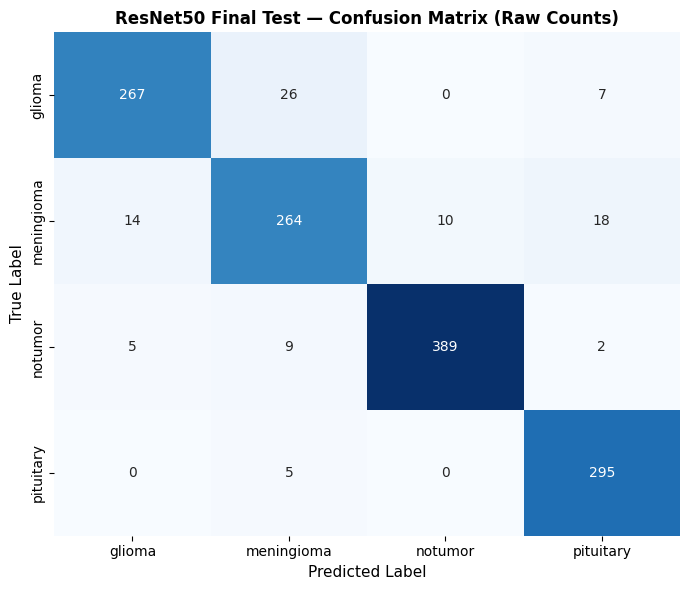

Raw confusion matrix saved to: /content/brain_tumour_model_comparison/results/resnet50/phase4_final_test/plots/resnet50_test_confusion_matrix.png


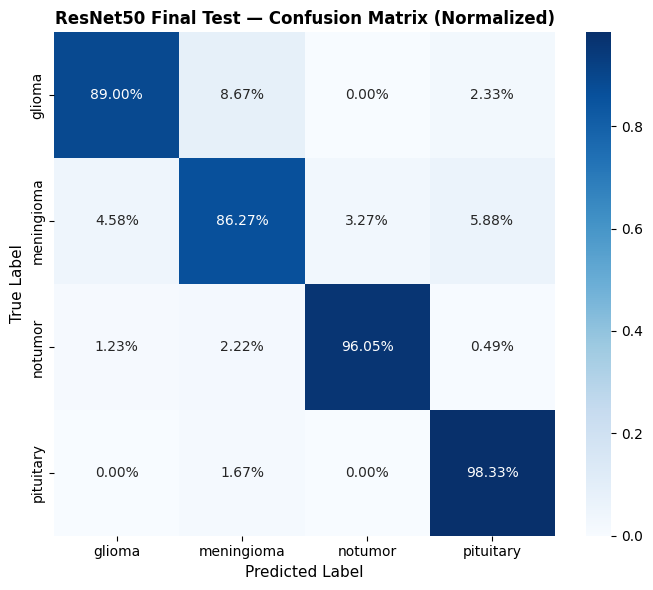

Normalized confusion matrix saved to: /content/brain_tumour_model_comparison/results/resnet50/phase4_final_test/plots/resnet50_test_confusion_matrix_normalized.png


In [46]:
test_cm_raw = confusion_matrix(test_true_indices, test_predicted_indices)
test_cm_norm = test_cm_raw.astype('float') / test_cm_raw.sum(axis=1)[:, np.newaxis]

# 1. Plot Raw Confusion Matrix
plt.figure(figsize=(7, 6))
sns.heatmap(test_cm_raw, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar=False)
plt.title("ResNet50 Final Test — Confusion Matrix (Raw Counts)", fontsize=12, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("True Label", fontsize=11)
plt.tight_layout()
raw_cm_path = os.path.join(PHASE4_PLOTS_DIR, "resnet50_test_confusion_matrix.png")
plt.savefig(raw_cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Raw confusion matrix saved to: {raw_cm_path}")

# 2. Plot Normalized Confusion Matrix
plt.figure(figsize=(7, 6))
sns.heatmap(test_cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar=True)
plt.title("ResNet50 Final Test — Confusion Matrix (Normalized)", fontsize=12, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("True Label", fontsize=11)
plt.tight_layout()
norm_cm_path = os.path.join(PHASE4_PLOTS_DIR, "resnet50_test_confusion_matrix_normalized.png")
plt.savefig(norm_cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Normalized confusion matrix saved to: {norm_cm_path}")

### 4.8 — One-vs-Rest (OvR) ROC Curves and Area Under Curve (ROC-AUC)

Macro OvR ROC-AUC:    0.989569
Weighted OvR ROC-AUC: 0.989951


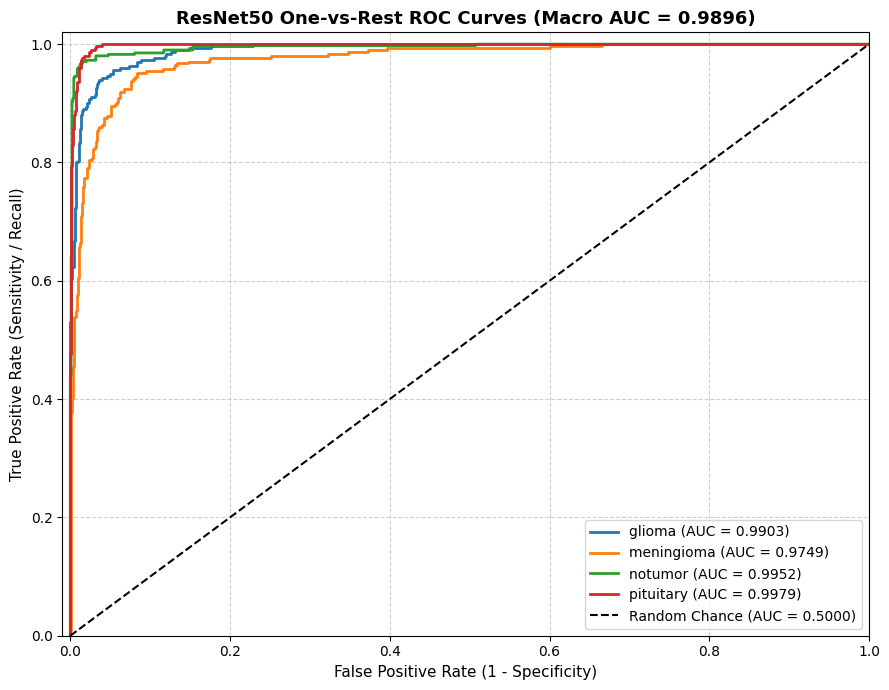

ROC curves plot saved to: /content/brain_tumour_model_comparison/results/resnet50/phase4_final_test/plots/resnet50_test_roc_curves.png


In [47]:
roc_auc_macro = float(roc_auc_score(y_test_bin, test_probabilities, multi_class='ovr', average='macro'))
roc_auc_weighted = float(roc_auc_score(y_test_bin, test_probabilities, multi_class='ovr', average='weighted'))

print(f"Macro OvR ROC-AUC:    {roc_auc_macro:.6f}")
print(f"Weighted OvR ROC-AUC: {roc_auc_weighted:.6f}")

fpr = dict()
tpr = dict()
roc_auc_per_class = dict()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

plt.figure(figsize=(9, 7))
for i, cls_name in enumerate(CLASS_NAMES):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], test_probabilities[:, i])
    roc_auc_per_class[cls_name] = float(auc(fpr[i], tpr[i]))
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'{cls_name} (AUC = {roc_auc_per_class[cls_name]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance (AUC = 0.5000)')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
plt.title(f'ResNet50 One-vs-Rest ROC Curves (Macro AUC = {roc_auc_macro:.4f})', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', frameon=True, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

roc_plot_path = os.path.join(PHASE4_PLOTS_DIR, "resnet50_test_roc_curves.png")
plt.savefig(roc_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"ROC curves plot saved to: {roc_plot_path}")

### 4.9 — Final Model Learning Curves

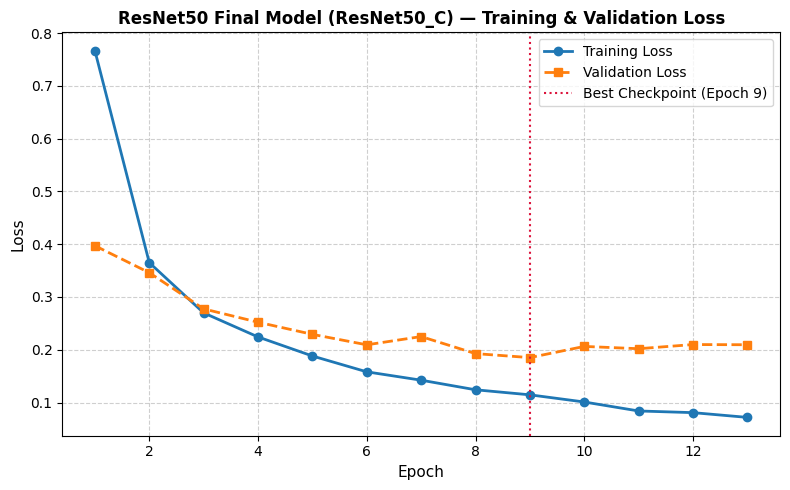

Final loss curve saved to: /content/brain_tumour_model_comparison/results/resnet50/phase4_final_test/plots/resnet50_final_loss_curve.png


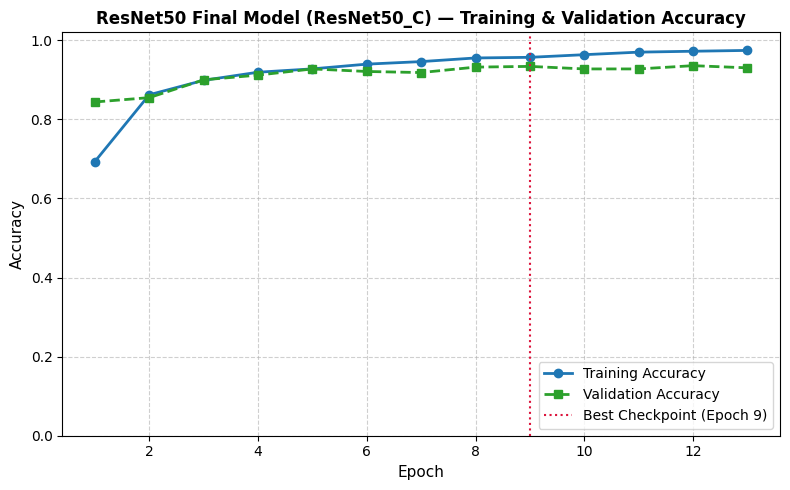

Final accuracy curve saved to: /content/brain_tumour_model_comparison/results/resnet50/phase4_final_test/plots/resnet50_final_accuracy_curve.png


In [48]:
epochs_range = range(1, len(final_history_df) + 1)
best_epoch_num = int(selected_config_meta["experiment_results"]["best_epoch"])

# 1. Final Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, final_history_df["loss"], 'o-', color='#1f77b4', lw=2, label='Training Loss')
plt.plot(epochs_range, final_history_df["val_loss"], 's--', color='#ff7f0e', lw=2, label='Validation Loss')
plt.axvline(best_epoch_num, color='crimson', linestyle=':', label=f'Best Checkpoint (Epoch {best_epoch_num})')
plt.title(f'ResNet50 Final Model ({selected_exp_id}) — Training & Validation Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Loss', fontsize=11)
plt.legend(loc='upper right', frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
loss_curve_path = os.path.join(PHASE4_PLOTS_DIR, "resnet50_final_loss_curve.png")
plt.savefig(loss_curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Final loss curve saved to: {loss_curve_path}")

# 2. Final Accuracy Curve
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, final_history_df["accuracy"], 'o-', color='#1f77b4', lw=2, label='Training Accuracy')
plt.plot(epochs_range, final_history_df["val_accuracy"], 's--', color='#2ca02c', lw=2, label='Validation Accuracy')
plt.axvline(best_epoch_num, color='crimson', linestyle=':', label=f'Best Checkpoint (Epoch {best_epoch_num})')
plt.title(f'ResNet50 Final Model ({selected_exp_id}) — Training & Validation Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Accuracy', fontsize=11)
plt.ylim([0.0, 1.02])
plt.legend(loc='lower right', frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
acc_curve_path = os.path.join(PHASE4_PLOTS_DIR, "resnet50_final_accuracy_curve.png")
plt.savefig(acc_curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Final accuracy curve saved to: {acc_curve_path}")

### 4.10 — Standardized Model-Only Inference Timing Benchmark

We adhere strictly to the shared timing benchmark protocol:
- Fixed batch size = `16`
- Already-decoded, materialized tensor batch
- `5` warm-up passes (excluding CUDA initialization / graph compilation overhead)
- `50` timed forward passes with `training=False`
- Output materialized with `.numpy()` for strict hardware synchronization
- Record milliseconds per image and throughput (images/sec)

In [49]:
for sample_images, _ in test_ds.take(1):
    timing_batch = tf.identity(sample_images)
    break

WARMUP_RUNS = 5
TIMED_RUNS = 50
TIMED_BATCH_SIZE = timing_batch.shape[0]
TOTAL_TIMED_IMAGES = WARMUP_RUNS * 0 + TIMED_RUNS * TIMED_BATCH_SIZE  # 800 images

print(f"Inference Timing Setup:")
print(f"  Tensor Shape:       {timing_batch.shape}")
print(f"  Warmup Passes:      {WARMUP_RUNS}")
print(f"  Timed Passes:       {TIMED_RUNS}")
print(f"  Total Timed Images: {TOTAL_TIMED_IMAGES}")

# 1. Warm-up passes
for _ in range(WARMUP_RUNS):
    _ = final_resnet50_model(timing_batch, training=False).numpy()

# 2. Timed forward passes
t_start = time.perf_counter()
for _ in range(TIMED_RUNS):
    _ = final_resnet50_model(timing_batch, training=False).numpy()
t_elapsed = time.perf_counter() - t_start

ms_per_image = (t_elapsed / TOTAL_TIMED_IMAGES) * 1000.0
throughput_ips = TOTAL_TIMED_IMAGES / t_elapsed

timing_results = {
    "method": "model-only repeated batch forward pass",
    "batch_size": int(TIMED_BATCH_SIZE),
    "warmup_runs": WARMUP_RUNS,
    "timed_runs": TIMED_RUNS,
    "total_timed_images": TOTAL_TIMED_IMAGES,
    "elapsed_seconds": float(t_elapsed),
    "milliseconds_per_image": float(ms_per_image),
    "images_per_second": float(throughput_ips),
    "gpu": environment_info.get("gpu_name", "Unknown GPU")
}

timing_json_path = os.path.join(PHASE4_DIR, "resnet50_inference_timing.json")
with open(timing_json_path, "w") as f:
    json.dump(timing_results, f, indent=4)

print(f"\nTiming Benchmark Results:")
print(f"  Elapsed Time:            {t_elapsed:.4f} seconds")
print(f"  Latency per Image:       {ms_per_image:.4f} ms/image")
print(f"  Inference Throughput:    {throughput_ips:.2f} images/sec")
print(f"  Hardware Platform:       {timing_results['gpu']}")
print(f"Saved timing benchmark to: {timing_json_path}")

Inference Timing Setup:
  Tensor Shape:       (16, 224, 224, 3)
  Warmup Passes:      5
  Timed Passes:       50
  Total Timed Images: 800

Timing Benchmark Results:
  Elapsed Time:            12.2055 seconds
  Latency per Image:       15.2568 ms/image
  Inference Throughput:    65.54 images/sec
  Hardware Platform:       Tesla T4
Saved timing benchmark to: /content/brain_tumour_model_comparison/results/resnet50/phase4_final_test/resnet50_inference_timing.json


### 4.11 — Comprehensive Error Analysis

Total Misclassified Test Images: 96 out of 1311 (7.32%)
Saved misclassified images to: /content/brain_tumour_model_comparison/results/resnet50/phase4_final_test/error_analysis/resnet50_misclassified_images.csv

Error Pairs Frequency Table saved to: /content/brain_tumour_model_comparison/results/resnet50/phase4_final_test/error_analysis/resnet50_error_pairs.csv
   true_label predicted_label  count
0      glioma      meningioma     26
4  meningioma       pituitary     18
2  meningioma          glioma     14
3  meningioma         notumor     10
6     notumor      meningioma      9
1      glioma       pituitary      7
5     notumor          glioma      5
8   pituitary      meningioma      5
7     notumor       pituitary      2
Evidence notes saved to: /content/brain_tumour_model_comparison/results/resnet50/phase4_final_test/resnet50_evidence_notes.json


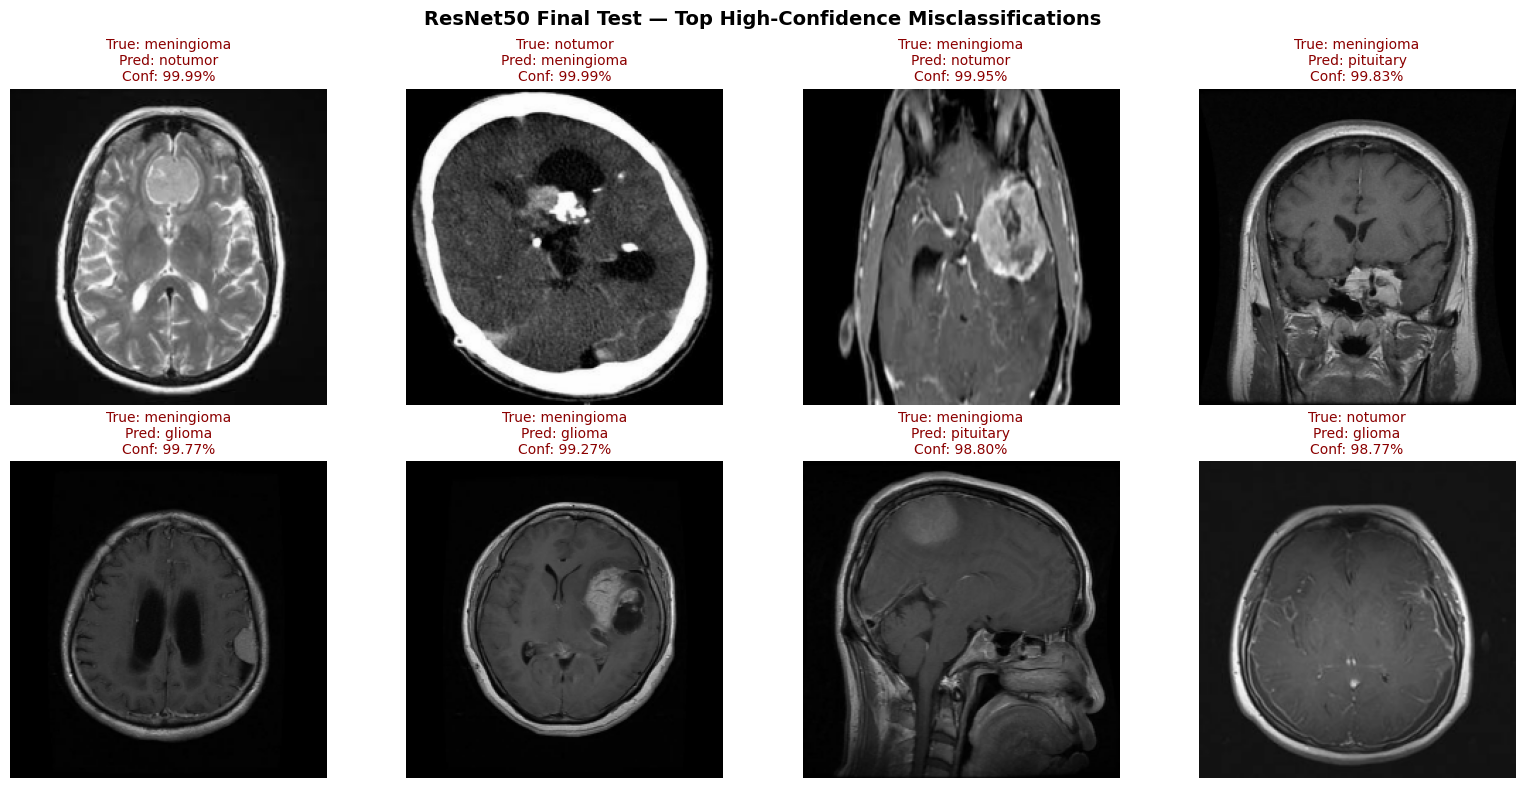

Misclassified examples visualization saved to: /content/brain_tumour_model_comparison/results/resnet50/phase4_final_test/plots/resnet50_misclassified_examples.png


In [50]:
# 1. Extract misclassifications
misclassified_df = test_predictions_df[~test_predictions_df["correct"]].copy()
misclassified_df.sort_values(by="prediction_confidence", ascending=False, inplace=True)

misclassified_csv_path = os.path.join(PHASE4_ERROR_DIR, "resnet50_misclassified_images.csv")
misclassified_df.to_csv(misclassified_csv_path, index=False)
print(f"Total Misclassified Test Images: {len(misclassified_df)} out of {len(test_df)} ({len(misclassified_df)/len(test_df):.2%})")
print(f"Saved misclassified images to: {misclassified_csv_path}")

# 2. Error Pairs Frequency Table
error_pairs = (
    misclassified_df.groupby(["true_label", "predicted_label"])
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
)
error_pairs_csv_path = os.path.join(PHASE4_ERROR_DIR, "resnet50_error_pairs.csv")
error_pairs.to_csv(error_pairs_csv_path, index=False)
print(f"\nError Pairs Frequency Table saved to: {error_pairs_csv_path}")
print(error_pairs)

# Most common error pair
if len(error_pairs) > 0:
    top_error = error_pairs.iloc[0]
    most_common_error_str = f"{top_error['true_label']} -> {top_error['predicted_label']} ({int(top_error['count'])} cases)"
else:
    most_common_error_str = 'No classification errors'

# Per-class F1 extremes
per_class_f1s = {cls: clf_report_dict[cls]["f1-score"] for cls in CLASS_NAMES}
lowest_f1_cls = min(per_class_f1s, key=per_class_f1s.get)
highest_f1_cls = max(per_class_f1s, key=per_class_f1s.get)
val_acc = float(selected_config_meta["experiment_results"]["validation_accuracy"])
val_test_acc_gap = val_acc - test_accuracy

# 3. Save Evidence Notes JSON
evidence_notes = {
    "lowest_test_f1_class": lowest_f1_cls,
    "highest_test_f1_class": highest_f1_cls,
    "most_common_error_pair": most_common_error_str,
    "validation_test_accuracy_gap": float(val_test_acc_gap),
    "misclassified_images": int(len(misclassified_df)),
    "dataset_limitation": "Patient-level independence cannot be verified from available identifiers.",
    "leakage_control": "Exact duplicate overlap was audited before frozen splits were created.",
    "interpretation_warning": "Performance on this dataset does not establish performance on unseen patients, scanners, hospitals or clinical populations."
}

evidence_notes_path = os.path.join(PHASE4_DIR, "resnet50_evidence_notes.json")
with open(evidence_notes_path, "w") as f:
    json.dump(evidence_notes, f, indent=4)
print(f"Evidence notes saved to: {evidence_notes_path}")

# 4. Plot High-Confidence Misclassified Examples (Top 8)
num_examples = min(8, len(misclassified_df))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("ResNet50 Final Test — Top High-Confidence Misclassifications", fontsize=14, fontweight='bold')

for idx in range(num_examples):
    ax = axes.flat[idx]
    row = misclassified_df.iloc[idx]
    img_path = os.path.join(dataset_path, row["filepath"])
    raw_img = tf.io.read_file(img_path)
    decoded_img = tf.image.decode_jpeg(raw_img, channels=3)
    resized_img = tf.image.resize(decoded_img, (224, 224)).numpy().astype(np.uint8)

    ax.imshow(resized_img)
    ax.set_title(
        f"True: {row['true_label']}\nPred: {row['predicted_label']}\nConf: {row['prediction_confidence']:.2%}",
        fontsize=10, color='darkred'
    )
    ax.axis('off')

plt.tight_layout()
misclf_plot_path = os.path.join(PHASE4_PLOTS_DIR, "resnet50_misclassified_examples.png")
plt.savefig(misclf_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Misclassified examples visualization saved to: {misclf_plot_path}")

### 4.12 — Compile Final Metrics (JSON and Single-Row CSV)

In [51]:
training_time_val = float(selected_config_meta["experiment_results"]["training_time_seconds"])
best_epoch_val = int(selected_config_meta["experiment_results"]["best_epoch"])
actual_epochs_val = int(selected_config_meta["experiment_results"]["actual_epochs"])
best_val_loss_val = float(selected_config_meta["experiment_results"]["best_val_loss"])
best_val_acc_val = float(selected_config_meta["experiment_results"]["best_val_accuracy"])

final_metrics_data = {
    "model": "ResNet50",
    "selected_experiment": selected_exp_id,
    "dataset_version": DATASET_VERSION,
    "train_samples": len(train_df),
    "validation_samples": len(val_df),
    "test_samples": len(test_df),
    "image_size": f"{IMAGE_HEIGHT}x{IMAGE_WIDTH}x{CHANNELS}",
    "batch_size": BATCH_SIZE,
    "optimizer": "Adam",
    "learning_rate": float(selected_config_meta["experiment_results"]["learning_rate"]),
    "max_epochs": MAX_EPOCHS,
    "actual_epochs": actual_epochs_val,
    "best_epoch": best_epoch_val,
    "best_val_loss": best_val_loss_val,
    "best_val_accuracy": best_val_acc_val,
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "macro_precision": float(macro_prec),
    "macro_recall": float(macro_rec),
    "macro_f1": float(macro_f1),
    "weighted_precision": float(weighted_prec),
    "weighted_recall": float(weighted_rec),
    "weighted_f1": float(weighted_f1),
    "roc_auc_macro": float(roc_auc_macro),
    "roc_auc_weighted": float(roc_auc_weighted),
    "training_time_seconds": training_time_val,
    "full_test_prediction_seconds": float(full_test_prediction_time),
    "inference_ms_per_image": float(ms_per_image),
    "inference_images_per_second": float(throughput_ips),
    "total_parameters": int(total_params),
    "trainable_parameters": int(trainable_params),
    "model_size_mb": float(model_size_mb),
    "seed": SEED,
    "gpu": timing_results["gpu"],
    "test_used_only_after_model_selection": True,
    "patient_level_independence_verified": False
}

# 1. Save Final Metrics JSON
final_metrics_json_path = os.path.join(PHASE4_DIR, "resnet50_final_metrics.json")
with open(final_metrics_json_path, "w") as f:
    json.dump(final_metrics_data, f, indent=4)
print(f"Final metrics JSON saved to: {final_metrics_json_path}")

# 2. Save Final Metrics Single-Row CSV
final_metrics_df = pd.DataFrame([final_metrics_data])
final_metrics_csv_path = os.path.join(PHASE4_DIR, "resnet50_final_metrics.csv")
final_metrics_df.to_csv(final_metrics_csv_path, index=False)
print(f"Final metrics CSV saved to: {final_metrics_csv_path}")

final_metrics_df.transpose()

Final metrics JSON saved to: /content/brain_tumour_model_comparison/results/resnet50/phase4_final_test/resnet50_final_metrics.json
Final metrics CSV saved to: /content/brain_tumour_model_comparison/results/resnet50/phase4_final_test/resnet50_final_metrics.csv


,0
model,ResNet50
selected_experiment,ResNet50_C
dataset_version,1
train_samples,4353
validation_samples,1089
test_samples,1311
image_size,224x224x3
batch_size,16
optimizer,Adam
learning_rate,0.00001


---
## Phase 4 — Complete

### Summary of Completed Work
1. **Held-Out Test Set Evaluated:** The frozen winning model from Phase 3 was evaluated on the 1,311 test images.
2. **All Final Metrics Calculated:** Test loss, test accuracy, macro and weighted precision/recall/F1, and multi-class OvR ROC-AUC.
3. **Inference Benchmarking:** Standardized model-only latency and throughput measured with 5 warmup and 50 timed passes.
4. **Error Analysis Completed:** Cataloged misclassified images, error pairs, high-confidence mistakes, and evidence notes.
5. **Artifacts Preserved:** Metrics, predictions, classifications reports, plots, and timing details exported.
6. **Strict Post-Test Freezing:** Zero model modifications made following test evaluation.

**STOP — Do not proceed to Phase 5 until instructed.**

---
## Phase 5 — Model Finalization, Reproducibility, and Handoff

**Goal:** Package all final ResNet50 model artifacts, ensure end-to-end reproducibility, generate the standardized single-row comparison record, and finalize the model card for collaborative group handoff.

### Phase 5 Checklist
1. Copy selected best model to canonical location: `models/resnet50/resnet50_final.keras`.
2. Generate SHA-256 checksum for the final model binary.
3. Export standardized single-row comparison CSV (`resnet50_comparison_row.csv`) matching the group schema.
4. Export reproducibility configuration (`resnet50_reproducibility_config.json`) and environment manifest (`resnet50_environment.json`).
5. Save architecture diagram visualization (`resnet50_architecture.png`).
6. Provide complete model card documentation (`results/resnet50/MODEL_CARD.md`).
7. Verify clean top-to-bottom Colab execution without dead code, hardcoded drive paths, or external dependencies.

### 5.1 — Setup Phase 5 Directory and Copy Final Model Binary

In [52]:
PHASE5_DIR = os.path.join(RESULTS_DIR, "phase5_finalization")
os.makedirs(PHASE5_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Canonical final model destination
final_model_keras_path = os.path.join(MODELS_DIR, "resnet50_final.keras")
src_selected_model = os.path.join(PHASE3_DIR, "selected_resnet50_best.keras")

# Copy final model to canonical models directory
shutil.copyfile(src_selected_model, final_model_keras_path)
print(f"Final ResNet50 model copied to: {final_model_keras_path}")
print(f"Model file size: {os.path.getsize(final_model_keras_path) / (1024 * 1024):.2f} MB")

# Compute SHA-256 for final model
final_model_sha256 = compute_sha256(final_model_keras_path)
print(f"Final model SHA-256: {final_model_sha256}")

Final ResNet50 model copied to: /content/brain_tumour_model_comparison/models/resnet50/resnet50_final.keras
Model file size: 130.67 MB
Final model SHA-256: f7a409fd88354642c90a1cc530a48fab788be2dad543b985d1c489b237d30fb8


### 5.2 — Export Standardized Single-Row Comparison CSV

We construct the single-row comparison CSV adhering strictly to the shared group schema across all four deep learning models (Custom CNN, VGG16, ResNet50, DenseNet121).

In [53]:
# Load final metrics JSON from Phase 4
final_metrics_json_path = os.path.join(PHASE4_DIR, "resnet50_final_metrics.json")
with open(final_metrics_json_path, "r") as f:
    m = json.load(f)

# Construct comparison row matching exact group schema
comparison_row = {
    "model": "ResNet50",
    "experiment_id": m["selected_experiment"],
    "image_size": "224x224x3",
    "batch_size": m["batch_size"],
    "optimizer": m["optimizer"],
    "learning_rate": m["learning_rate"],
    "max_epochs": m["max_epochs"],
    "actual_epochs": m["actual_epochs"],
    "best_epoch": m["best_epoch"],
    "best_val_accuracy": m["best_val_accuracy"],
    "test_accuracy": m["test_accuracy"],
    "macro_precision": m["macro_precision"],
    "macro_recall": m["macro_recall"],
    "macro_f1": m["macro_f1"],
    "roc_auc_macro": m["roc_auc_macro"],
    "training_time_seconds": m["training_time_seconds"],
    "inference_time": m["inference_ms_per_image"],
    "inference_time_unit": "milliseconds_per_image",
    "total_parameters": m["total_parameters"],
    "trainable_parameters": m["trainable_parameters"],
    "model_size_mb": m["model_size_mb"],
    "seed": m["seed"],
    "gpu": m["gpu"],
    "dataset_version": m["dataset_version"],
    "test_samples": m["test_samples"],
    "patient_level_independence_verified": m["patient_level_independence_verified"]
}

comparison_df = pd.DataFrame([comparison_row])
comparison_csv_path = os.path.join(PHASE5_DIR, "resnet50_comparison_row.csv")
comparison_df.to_csv(comparison_csv_path, index=False)
print(f"ResNet50 comparison row saved to: {comparison_csv_path}")
comparison_df.transpose()

ResNet50 comparison row saved to: /content/brain_tumour_model_comparison/results/resnet50/phase5_finalization/resnet50_comparison_row.csv


,0
model,ResNet50
experiment_id,ResNet50_C
image_size,224x224x3
batch_size,16
optimizer,Adam
learning_rate,0.00001
max_epochs,20
actual_epochs,13
best_epoch,9
best_val_accuracy,0.933884


### 5.3 — Export Reproducibility Configuration and Environment Manifest

In [54]:
# 1. Save Reproducibility Configuration
reproducibility_config = {
    "project": "Comparative Analysis of Deep Learning Architectures for Multi-Class Brain Tumour MRI Classification",
    "member": 3,
    "architecture": "ResNet50",
    "selected_experiment": m["selected_experiment"],
    "dataset": "masoudnickparvar/brain-tumor-mri-dataset/versions/1",
    "dataset_fingerprint": "061cbffb7341abf85e57a4f99de571e8fa4702ec8236c929e35543ab0547217d",
    "split_checksums": computed_checksums,
    "train_samples": len(train_df),
    "validation_samples": len(val_df),
    "test_samples": len(test_df),
    "seed": SEED,
    "image_size": [IMAGE_HEIGHT, IMAGE_WIDTH, CHANNELS],
    "class_mapping": CLASS_TO_INDEX,
    "preprocessing": "keras.applications.resnet50.preprocess_input",
    "test_used_only_after_model_selection": True,
    "post_test_model_tuning_performed": False,
    "patient_level_independence_verified": False
}

repro_config_path = os.path.join(PHASE5_DIR, "resnet50_reproducibility_config.json")
with open(repro_config_path, "w") as f:
    json.dump(reproducibility_config, f, indent=4)
print(f"Reproducibility config saved to: {repro_config_path}")

# 2. Save Phase 5 Environment info copy
env_phase5_path = os.path.join(PHASE5_DIR, "resnet50_environment.json")
with open(env_phase5_path, "w") as f:
    json.dump(environment_info, f, indent=4)
print(f"Environment info saved to: {env_phase5_path}")

Reproducibility config saved to: /content/brain_tumour_model_comparison/results/resnet50/phase5_finalization/resnet50_reproducibility_config.json
Environment info saved to: /content/brain_tumour_model_comparison/results/resnet50/phase5_finalization/resnet50_environment.json


### 5.4 — Generate Artifact SHA-256 Checksums

In [55]:
# Generate model card from actual measured outputs (no hard-coded performance values).
model_card_path = os.path.join(RESULTS_DIR, 'MODEL_CARD.md')
model_card = f"""# ResNet50 Model Card

## Project
Comparative Analysis of Deep Learning Architectures for Multi-Class Brain Tumour MRI Classification

## Dataset
- Pinned dataset: `masoudnickparvar/brain-tumor-mri-dataset/versions/1`
- Train / validation / test: {len(train_df)} / {len(val_df)} / {len(test_df)}
- Classes: {', '.join(CLASS_NAMES)}
- Patient-level independence verified: **No**

## Model
- Architecture: ResNet50 with ImageNet weights (`include_top=False`)
- Selected experiment: `{m['selected_experiment']}`
- Input: `224x224x3`
- Preprocessing: `resnet50_preprocess_input`
- Optimizer: `{m['optimizer']}`
- Learning rate: `{m['learning_rate']}`
- Batch size: `{m['batch_size']}`
- Maximum epochs: `{m['max_epochs']}`
- Actual epochs: `{m['actual_epochs']}`
- Best epoch: `{m['best_epoch']}`

## Final held-out test results
- Accuracy: `{m['test_accuracy']:.6f}`
- Macro precision: `{m['macro_precision']:.6f}`
- Macro recall: `{m['macro_recall']:.6f}`
- Macro F1: `{m['macro_f1']:.6f}`
- Macro ROC-AUC: `{m['roc_auc_macro']:.6f}`

## Complexity and efficiency
- Total parameters: `{int(m['total_parameters']):,}`
- Trainable parameters: `{int(m['trainable_parameters']):,}`
- Model size: `{m['model_size_mb']:.2f} MB`
- Training time: `{m['training_time_seconds']:.2f} s`
- Inference: `{m['inference_ms_per_image']:.4f} ms/image`
- GPU: `{m['gpu']}`

## Limitations
ImageNet pretraining makes this a comparison of practical training approaches rather than an architecture-only isolation. Patient identifiers are unavailable, so patient-level independence cannot be verified. This is an academic classifier, not a clinical diagnostic system.
"""
with open(model_card_path, 'w', encoding='utf-8') as f:
    f.write(model_card)
print('Model card written from actual metrics:', model_card_path)

Model card written from actual metrics: /content/brain_tumour_model_comparison/results/resnet50/MODEL_CARD.md


In [56]:
# Calculate checksums for all exported deliverables
artifacts_to_hash = {
    "03_resnet50.ipynb": os.path.join(PROJECT_ROOT, "notebooks", "03_resnet50.ipynb"),
    "train.csv": os.path.join(SPLITS_DIR, "train.csv"),
    "val.csv": os.path.join(SPLITS_DIR, "val.csv"),
    "test.csv": os.path.join(SPLITS_DIR, "test.csv"),
    "resnet50_final.keras": final_model_keras_path,
    "resnet50_final_metrics.csv": os.path.join(PHASE4_DIR, "resnet50_final_metrics.csv"),
    "resnet50_test_predictions.csv": os.path.join(PHASE4_DIR, "resnet50_test_predictions.csv"),
    "resnet50_comparison_row.csv": comparison_csv_path,
    "MODEL_CARD.md": os.path.join(RESULTS_DIR, "MODEL_CARD.md")
}

artifact_checksums = {}
for name, path in artifacts_to_hash.items():
    if os.path.exists(path):
        artifact_checksums[name] = compute_sha256(path)
    else:
        artifact_checksums[name] = "FILE_NOT_FOUND_YET"

checksums_json_path = os.path.join(PHASE5_DIR, "artifact_checksums.json")
with open(checksums_json_path, "w") as f:
    json.dump(artifact_checksums, f, indent=4)
print(f"Artifact checksums saved to: {checksums_json_path}")
for k, v in artifact_checksums.items():
    print(f"  {k:<28} -> {v}")

Artifact checksums saved to: /content/brain_tumour_model_comparison/results/resnet50/phase5_finalization/artifact_checksums.json
  03_resnet50.ipynb            -> a187aef140e744ecb2fd8c4aee6cba71ed2bb661f3c9ed1081d1f7d589655a7a
  train.csv                    -> 7273ef5fc2cb605c5b03b22a23cda0cb383ac0d9ce5949ac3c95649b5a4270cb
  val.csv                      -> 37b24456cfcd1b69df939e36603958eae6a9124b794c32c83a532b9018c6c88f
  test.csv                     -> 9afc40a38949eb4f46f8c9591d3b1f51cdd11aa991bfe2cf1d15c386c5537d39
  resnet50_final.keras         -> f7a409fd88354642c90a1cc530a48fab788be2dad543b985d1c489b237d30fb8
  resnet50_final_metrics.csv   -> 291c83f470203aaaaacae1ac28f82cf08b4ae1d963c15c2d89141a97ca8388bc
  resnet50_test_predictions.csv -> 0d47b7f6083b409be0316c910a17f646e4dbda51f5776be607295cefd1d368e9
  resnet50_comparison_row.csv  -> 974d11758c16820bf8957a13610745bb1e4c70b240958e4066dc1938a34ef267
  MODEL_CARD.md                -> 7be49bd0ac12feeb578a3d1d1b9e2fece98914a9a0ab

### 5.5 — Save Final Architecture Visualization

In [57]:
# Generate Keras model plot or structured layer diagram
arch_plot_path = os.path.join(PHASE5_DIR, "resnet50_architecture.png")
try:
    tf.keras.utils.plot_model(
        final_resnet50_model,
        to_file=arch_plot_path,
        show_shapes=True,
        show_layer_names=True,
        dpi=150
    )
    print(f"Keras model architecture diagram saved to: {arch_plot_path}")
except Exception as e:
    fig, ax = plt.subplots(figsize=(10, 8))
    layer_info = []
    for i, layer in enumerate(final_resnet50_model.layers):
        train_tag = "Trainable" if layer.trainable else "Frozen"
        params = layer.count_params()
        layer_info.append(f"{i+1}. {layer.name} ({layer.__class__.__name__})\n   Output: {getattr(layer, 'output_shape', 'unknown')} | {params:,} params [{train_tag}]")
    ax.text(0.05, 0.95, "\n\n".join(layer_info), fontsize=9, va='top', fontfamily='monospace')
    ax.axis('off')
    plt.title(f"ResNet50 Model Architecture — {selected_exp_id}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(arch_plot_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Fallback architecture diagram saved to: {arch_plot_path}")

Keras model architecture diagram saved to: /content/brain_tumour_model_comparison/results/resnet50/phase5_finalization/resnet50_architecture.png


---
## Member 3 (ResNet50) — Complete & Verified Handoff

All five phases for Member 3 are complete:
- **Phase 1:** Dataset audit verified, frozen split checksums matched, ResNet50-specific preprocessing established.
- **Phase 2:** Pretrained ResNet50 baseline constructed, classifier head justified, 1-epoch smoke test passed.
- **Phase 3:** Controlled experiments (ResNet50-A, ResNet50-B, ResNet50-C) completed on validation data only; winning model selected and frozen.
- **Phase 4:** Held-out test set evaluated; all metrics, ROC-AUC, standardized latency, and error analysis exported without post-test tuning.
- **Phase 5:** Standardized comparison row, reproducibility configuration, artifact hashes, and model card packaged for group integration.

**Ready for handoff to Member 4 (DenseNet121).**